# 数据导入和处理

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')
import seaborn as sns
import numpy as np
import json
import warnings
warnings.filterwarnings('ignore')
import base64
import io
from matplotlib.pyplot import imread
import codecs
from IPython.display import HTML
import csv 
import numpy as np 

In [2]:
sns.set_style('darkgrid')
#加载词云包
from wordcloud import WordCloud,STOPWORDS   

In [3]:
movies = pd.read_csv('F:/大三（上）/机器学习/机器学习期末报告/机器学习期末报告/电影数据分析/data/tmdb_5000_movies.csv',engine='python')    
credits = pd.read_csv('F:/大三（上）/机器学习/机器学习期末报告/机器学习期末报告/电影数据分析/data/tmdb_5000_credits.csv',engine='python')  

In [4]:
#json数据解析
json_cols = ['genres','keywords', 'spoken_languages', 'production_companies', 'production_countries']
for i in json_cols:
    movies[i] = movies[i].apply(json.loads)
def get_names(x):
    return ','.join([i['name'] for i in x])
movies['genres'] = movies['genres'].apply(get_names)
movies['keywords'] = movies['keywords'].apply(get_names)          
movies['spoken_languages'] = movies['spoken_languages'].apply(get_names)
movies['production_countries'] = movies['production_countries'].apply(get_names) 
movies['production_companies'] = movies['production_companies'].apply(get_names)

In [5]:
pd.set_option('display.max_columns', None) # 显示所有列
display(movies.sample(3))
display(credits.sample(3)) 

,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,title,vote_average,vote_count
2766,0,"Adventure,Comedy,Drama,Romance",NaN,9683,"lovesickness,niagara falls,crush,youth,illness",en,Bubble Boy,Jimmy is young man who was born without an imm...,10.131123,Touchstone Pictures,United States of America,2001-08-24,0,84.0,English,Released,Life is an adventure. Don't blow it.,Bubble Boy,5.1,163
778,60000000,"Comedy,Science Fiction,Adventure,Family",http://www.meetdavemovie.com/,11260,"new york,captain,starships,new love,earth,frie...",en,Meet Dave,A crew of miniature aliens operate a spaceship...,18.676291,"Twentieth Century Fox Film Corporation,Dune En...",United States of America,2008-07-08,50650079,90.0,English,Released,There's a Whole Other World Going on Inside of...,Meet Dave,5.0,371
2953,11000000,"Drama,Adventure,Romance",NaN,13888,"island,marooned,pacific island,teenager,desert...",en,Return to the Blue Lagoon,"In this sequel to the 1980 classic, two childr...",9.705589,Columbia Pictures Corporation,Fiji,1991-08-02,2807854,98.0,English,Released,"Return to the Romance, Return to the Adventure...",Return to the Blue Lagoon,5.1,153


,movie_id,title,cast,crew
1791,22894,Legion,"[{""cast_id"": 1, ""character"": ""Michael"", ""credi...","[{""credit_id"": ""534f9032c3a3681cae0008ce"", ""de..."
3345,8390,"Definitely, Maybe","[{""cast_id"": 1, ""character"": ""Will Hayes"", ""cr...","[{""credit_id"": ""52fe44a4c3a36847f80a1deb"", ""de..."
1862,14177,Beauty Shop,"[{""cast_id"": 4, ""character"": ""Gina Norris"", ""c...","[{""credit_id"": ""52fe45d59251416c75063f8f"", ""de..."


In [6]:
movies.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4803 entries, 0 to 4802
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   budget                4803 non-null   int64  
 1   genres                4803 non-null   object 
 2   homepage              1712 non-null   object 
 3   id                    4803 non-null   int64  
 4   keywords              4803 non-null   object 
 5   original_language     4803 non-null   object 
 6   original_title        4803 non-null   object 
 7   overview              4800 non-null   object 
 8   popularity            4803 non-null   float64
 9   production_companies  4803 non-null   object 
 10  production_countries  4803 non-null   object 
 11  release_date          4802 non-null   object 
 12  revenue               4803 non-null   int64  
 13  runtime               4801 non-null   float64
 14  spoken_languages      4803 non-null   object 
 15  status               

In [7]:
movies.describe() 

,budget,id,popularity,revenue,runtime,vote_average,vote_count
count,4.803000e+03,4803.000000,4803.000000,4.803000e+03,4801.000000,4803.000000,4803.000000
mean,2.904504e+07,57165.484281,21.492301,8.226064e+07,106.875859,6.092172,690.217989
std,4.072239e+07,88694.614033,31.816650,1.628571e+08,22.611935,1.194612,1234.585891
min,0.000000e+00,5.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000
25%,7.900000e+05,9014.500000,4.668070,0.000000e+00,94.000000,5.600000,54.000000
50%,1.500000e+07,14629.000000,12.921594,1.917000e+07,103.000000,6.200000,235.000000
75%,4.000000e+07,58610.500000,28.313505,9.291719e+07,118.000000,6.800000,737.000000
max,3.800000e+08,459488.000000,875.581305,2.787965e+09,338.000000,10.000000,13752.000000


In [8]:
credits.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4803 entries, 0 to 4802
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   movie_id  4803 non-null   int64 
 1   title     4803 non-null   object
 2   cast      4803 non-null   object
 3   crew      4803 non-null   object
dtypes: int64(1), object(3)
memory usage: 150.2+ KB


In [9]:
columns = movies.columns

## 数据清洗

In [10]:
# 查看缺失值
movies.isnull().sum()

budget                     0
genres                     0
homepage                3091
id                         0
keywords                   0
original_language          0
original_title             0
overview                   3
popularity                 0
production_companies       0
production_countries       0
release_date               1
revenue                    0
runtime                    2
spoken_languages           0
status                     0
tagline                  844
title                      0
vote_average               0
vote_count                 0
dtype: int64

In [11]:
#deleted columns 
deleted_columns = ['homepage', 'tagline', 'overview','status']
#drop it from our movies
movies.drop(deleted_columns,axis = 1 ,inplace = True) 

In [12]:
movies.head() 

,budget,genres,id,keywords,original_language,original_title,popularity,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,title,vote_average,vote_count
0,237000000,"Action,Adventure,Fantasy,Science Fiction",19995,"culture clash,future,space war,space colony,so...",en,Avatar,150.437577,"Ingenious Film Partners,Twentieth Century Fox ...","United States of America,United Kingdom",2009-12-10,2787965087,162.0,"English,Español",Avatar,7.2,11800
1,300000000,"Adventure,Fantasy,Action",285,"ocean,drug abuse,exotic island,east india trad...",en,Pirates of the Caribbean: At World's End,139.082615,"Walt Disney Pictures,Jerry Bruckheimer Films,S...",United States of America,2007-05-19,961000000,169.0,English,Pirates of the Caribbean: At World's End,6.9,4500
2,245000000,"Action,Adventure,Crime",206647,"spy,based on novel,secret agent,sequel,mi6,bri...",en,Spectre,107.376788,"Columbia Pictures,Danjaq,B24","United Kingdom,United States of America",2015-10-26,880674609,148.0,"Français,English,Español,Italiano,Deutsch",Spectre,6.3,4466
3,250000000,"Action,Crime,Drama,Thriller",49026,"dc comics,crime fighter,terrorist,secret ident...",en,The Dark Knight Rises,112.312950,"Legendary Pictures,Warner Bros.,DC Entertainme...",United States of America,2012-07-16,1084939099,165.0,English,The Dark Knight Rises,7.6,9106
4,260000000,"Action,Adventure,Science Fiction",49529,"based on novel,mars,medallion,space travel,pri...",en,John Carter,43.926995,Walt Disney Pictures,United States of America,2012-03-07,284139100,132.0,English,John Carter,6.1,2124


In [13]:
movies.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4803 entries, 0 to 4802
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   budget                4803 non-null   int64  
 1   genres                4803 non-null   object 
 2   id                    4803 non-null   int64  
 3   keywords              4803 non-null   object 
 4   original_language     4803 non-null   object 
 5   original_title        4803 non-null   object 
 6   popularity            4803 non-null   float64
 7   production_companies  4803 non-null   object 
 8   production_countries  4803 non-null   object 
 9   release_date          4802 non-null   object 
 10  revenue               4803 non-null   int64  
 11  runtime               4801 non-null   float64
 12  spoken_languages      4803 non-null   object 
 13  title                 4803 non-null   object 
 14  vote_average          4803 non-null   float64
 15  vote_count           

In [14]:
#deleted columns 
deleted_columns1 = ['title', 'movie_id']
#drop it from our movies
credits.drop(deleted_columns1,axis = 1 ,inplace = True) 

In [15]:
# 合并2个数据集
fullDF=pd.concat([movies,credits],axis=1) 

In [16]:
credits.isnull().sum() 

cast    0
crew    0
dtype: int64

In [17]:
# 填补缺失值
nanX=fullDF['runtime'].isnull()
fullDF.loc[nanX,:] 

,budget,genres,id,keywords,original_language,original_title,popularity,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,title,vote_average,vote_count,cast,crew
2656,15000000,Drama,370980,"pope,biography",it,Chiamatemi Francesco - Il Papa della gente,0.738646,Taodue Film,Italy,2015-12-03,0,NaN,Español,Chiamatemi Francesco - Il Papa della gente,7.3,12,"[{""cast_id"": 5, ""character"": ""Jorge Mario Berg...","[{""credit_id"": ""5660019ac3a36875f100252b"", ""de..."
4140,2,Documentary,459488,"music,actors,legendary perfomer,classic hollyw...",en,"To Be Frank, Sinatra at 100",0.050625,Eyeline Entertainment,United Kingdom,2015-12-12,0,NaN,,"To Be Frank, Sinatra at 100",0.0,0,"[{""cast_id"": 0, ""character"": ""Narrator"", ""cred...","[{""credit_id"": ""592b25e4c3a368783e065a2f"", ""de..."


In [18]:
fullDF.loc[2656,'runtime']='98'
fullDF.loc[4140,'runtime']='82'
fullDF.loc[nanX,:]  

,budget,genres,id,keywords,original_language,original_title,popularity,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,title,vote_average,vote_count,cast,crew
2656,15000000,Drama,370980,"pope,biography",it,Chiamatemi Francesco - Il Papa della gente,0.738646,Taodue Film,Italy,2015-12-03,0,98,Español,Chiamatemi Francesco - Il Papa della gente,7.3,12,"[{""cast_id"": 5, ""character"": ""Jorge Mario Berg...","[{""credit_id"": ""5660019ac3a36875f100252b"", ""de..."
4140,2,Documentary,459488,"music,actors,legendary perfomer,classic hollyw...",en,"To Be Frank, Sinatra at 100",0.050625,Eyeline Entertainment,United Kingdom,2015-12-12,0,82,,"To Be Frank, Sinatra at 100",0.0,0,"[{""cast_id"": 0, ""character"": ""Narrator"", ""cred...","[{""credit_id"": ""592b25e4c3a368783e065a2f"", ""de..."


In [19]:
nanX1=fullDF['release_date'].isnull()
fullDF.loc[nanX1,:]  

,budget,genres,id,keywords,original_language,original_title,popularity,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,title,vote_average,vote_count,cast,crew
4553,0,,380097,,en,America Is Still the Place,0.0,,,NaN,0,0,,America Is Still the Place,0.0,0,[],[]


In [20]:
fullDF.loc[4553,'release_date']='2014/6/1'
fullDF.loc[nanX1,:]  

,budget,genres,id,keywords,original_language,original_title,popularity,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,title,vote_average,vote_count,cast,crew
4553,0,,380097,,en,America Is Still the Place,0.0,,,2014/6/1,0,0,,America Is Still the Place,0.0,0,[],[]


In [21]:
fullDF.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4803 entries, 0 to 4802
Data columns (total 18 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   budget                4803 non-null   int64  
 1   genres                4803 non-null   object 
 2   id                    4803 non-null   int64  
 3   keywords              4803 non-null   object 
 4   original_language     4803 non-null   object 
 5   original_title        4803 non-null   object 
 6   popularity            4803 non-null   float64
 7   production_companies  4803 non-null   object 
 8   production_countries  4803 non-null   object 
 9   release_date          4803 non-null   object 
 10  revenue               4803 non-null   int64  
 11  runtime               4803 non-null   object 
 12  spoken_languages      4803 non-null   object 
 13  title                 4803 non-null   object 
 14  vote_average          4803 non-null   float64
 15  vote_count           

In [22]:
# 将release_date的数据类型转化成日期类型
fullDF.loc[:,'release_date']=pd.to_datetime(fullDF.loc[:,'release_date'],format='%Y-%m-%d',errors='coerce')
fullDF.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4803 entries, 0 to 4802
Data columns (total 18 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   budget                4803 non-null   int64         
 1   genres                4803 non-null   object        
 2   id                    4803 non-null   int64         
 3   keywords              4803 non-null   object        
 4   original_language     4803 non-null   object        
 5   original_title        4803 non-null   object        
 6   popularity            4803 non-null   float64       
 7   production_companies  4803 non-null   object        
 8   production_countries  4803 non-null   object        
 9   release_date          4803 non-null   datetime64[ns]
 10  revenue               4803 non-null   int64         
 11  runtime               4803 non-null   object        
 12  spoken_languages      4803 non-null   object        
 13  title             

In [23]:
# 异常值处理
# 对预算、票房、受欢迎程度、评分、评分次数中为0的数值用平均值替代
fullDF['budget'].replace(0, fullDF['budget'].mean(), inplace=True)
fullDF['revenue'].replace(0, fullDF['revenue'].mean(), inplace=True)
fullDF['popularity'].replace(0, fullDF['popularity'].mean(), inplace=True)
fullDF['vote_average'].replace(0, fullDF['vote_average'].mean(), inplace=True)
fullDF['vote_count'].replace(0, fullDF['vote_count'].mean(), inplace=True)
fullDF.describe() 

,budget,id,popularity,revenue,vote_average,vote_count
count,4.803000e+03,4803.000000,4803.000000,4.803000e+03,4803.000000,4803.000000
mean,3.531606e+07,57165.484281,21.496775,1.067008e+08,6.172081,699.127736
std,3.790514e+07,88694.614033,31.815138,1.546419e+08,0.966326,1232.060053
min,1.000000e+00,5.000000,0.000372,5.000000e+00,0.500000,1.000000
25%,1.200000e+07,9014.500000,4.674558,2.760697e+07,5.600000,59.000000
50%,2.904504e+07,14629.000000,12.928269,8.226064e+07,6.200000,250.000000
75%,4.000000e+07,58610.500000,28.313505,9.291719e+07,6.800000,737.000000
max,3.800000e+08,459488.000000,875.581305,2.787965e+09,10.000000,13752.000000


In [24]:
fullDF['release_year'] = pd.DatetimeIndex(fullDF['release_date']).year
fullDF['release_month'] = pd.DatetimeIndex(fullDF['release_date']).month
fullDF['release_day'] = pd.DatetimeIndex(fullDF['release_date']).day
fullDF['release_dow'] = pd.DatetimeIndex(fullDF['release_date']).dayofweek

# 描述性分析

In [22]:
# 将电影发行日期作为索引
fullDF.index = fullDF['release_date']
fullDF.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 4803 entries, 2009-12-10 to 2005-08-05
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   budget                4803 non-null   float64       
 1   genres                4803 non-null   object        
 2   id                    4803 non-null   int64         
 3   keywords              4803 non-null   object        
 4   popularity            4803 non-null   float64       
 5   production_companies  4803 non-null   object        
 6   production_countries  4803 non-null   object        
 7   release_date          4803 non-null   datetime64[ns]
 8   revenue               4803 non-null   float64       
 9   runtime               4803 non-null   object        
 10  title                 4803 non-null   object        
 11  vote_average          4803 non-null   float64       
 12  vote_count            4803 non-null   float64       
 13  

In [23]:
# 按时间排序
fullDF.sort_index(ascending=True, inplace=True)
fullDF.head(3)

,budget,genres,id,keywords,popularity,production_companies,production_countries,release_date,revenue,runtime,title,vote_average,vote_count,cast,crew
release_date,,,,,,,,,,,,,,,
1916-09-04,385907.0,"[{""id"": 18, ""name"": ""Drama""}]",3059,"[{""id"": 279, ""name"": ""usa""}, {""id"": 2487, ""nam...",3.232447,"[{""name"": ""Triangle Film Corporation"", ""id"": 1...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",1916-09-04,8394751.0,197,Intolerance,7.4,60.0,"[{""cast_id"": 23, ""character"": ""The Woman Who R...","[{""credit_id"": ""577fe3e79251415db5000bf2"", ""de..."
1925-11-05,245000.0,"[{""id"": 18, ""name"": ""Drama""}, {""id"": 10749, ""n...",3060,"[{""id"": 2504, ""name"": ""world war i""}, {""id"": 1...",0.785744,"[{""name"": ""Metro-Goldwyn-Mayer (MGM)"", ""id"": 8...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",1925-11-05,22000000.0,151,The Big Parade,7.0,21.0,"[{""cast_id"": 23, ""character"": ""James Apperson""...","[{""credit_id"": ""52fe4381c3a36847f805922b"", ""de..."
1927-01-10,92620000.0,"[{""id"": 18, ""name"": ""Drama""}, {""id"": 878, ""nam...",19,"[{""id"": 312, ""name"": ""man vs machine""}, {""id"":...",32.351527,"[{""name"": ""Paramount Pictures"", ""id"": 4}, {""na...","[{""iso_3166_1"": ""DE"", ""name"": ""Germany""}]",1927-01-10,650422.0,153,Metropolis,8.0,657.0,"[{""cast_id"": 10, ""character"": ""Maria"", ""credit...","[{""credit_id"": ""52fe420fc3a36847f8000c55"", ""de..."


## 数据分析

###  观众喜欢什么电影类型?有什么主题关键词?

In [245]:
pop_gen = pd.DataFrame(gen_df['genre'].value_counts()).reset_index()
pop_gen.columns = ['genre', 'movies']
pop_gen.head(10)  

,genre,movies
0,Drama,2297
1,Comedy,1722
2,Thriller,1274
3,Action,1154
4,Romance,894
5,Adventure,790
6,Crime,696
7,Science Fiction,535
8,Horror,519
9,Family,513


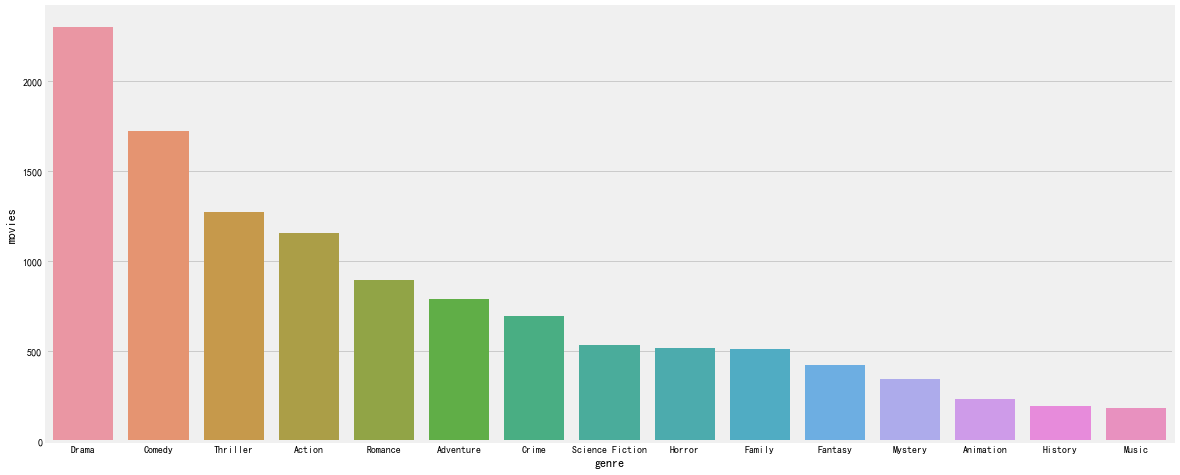

In [246]:
plt.figure(figsize=(18,8))
sns.barplot(x='genre', y='movies', data=pop_gen.head(15))
plt.show()  

In [454]:
key1 = pd.DataFrame(fullDF['keywords'].value_counts()).reset_index()
key1.columns = ['keywords', 'movies']
key1.head(10)  

,keywords,movies
0,,412
1,independent film,55
2,woman director,42
3,duringcreditsstinger,15
4,sport,13
5,"independent film,woman director",10
6,musical,5
7,suspense,5
8,biography,5
9,gay,3


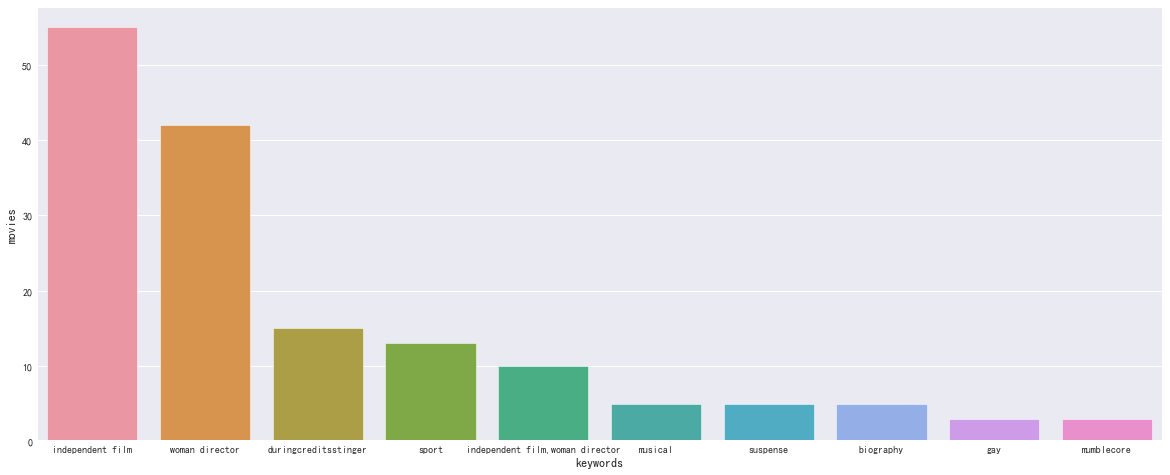

In [466]:
plt.figure(figsize=(18,8))
sns.barplot(x='keywords', y='movies', data=key1.drop([0]).head(10))
plt.show()  

In [29]:
# 创建一个包含电影类型，且以发行时间为索引的数据集
index = fullDF.index
genres_year = pd.DataFrame(index=index, columns=genres)
# 用0来填充NaN
genres_year.fillna(0, inplace=True)
genres_year.head()

,TV Movie,Family,History,Drama,Documentary,Romance,Crime,Fantasy,Animation,Science Fiction,Adventure,Mystery,Foreign,Thriller,Comedy,Music,Action,Horror,War,Western
release_date,,,,,,,,,,,,,,,,,,,,
1916-09-04,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1925-11-05,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1927-01-10,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1929-01-30,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1929-02-08,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [30]:
# 在genres_year数据集中添加数据
for m in range(len(fullDF)):
    genres_j = json.loads(fullDF['genres'][m])
    for n in range(len(genres_j)):
        word = genres_j[n]['name']
        genres_year.loc[genres_year.index[m], word] += 1
genres_year.head()

,TV Movie,Family,History,Drama,Documentary,Romance,Crime,Fantasy,Animation,Science Fiction,Adventure,Mystery,Foreign,Thriller,Comedy,Music,Action,Horror,War,Western
release_date,,,,,,,,,,,,,,,,,,,,
1916-09-04,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1925-11-05,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0
1927-01-10,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0
1929-01-30,0,0,0,1,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0
1929-02-08,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0


In [31]:
# 将索引转为为年的日期形式
genres_year = genres_year.resample('Y').sum().to_period('Y')
genres_year.head()

,TV Movie,Family,History,Drama,Documentary,Romance,Crime,Fantasy,Animation,Science Fiction,Adventure,Mystery,Foreign,Thriller,Comedy,Music,Action,Horror,War,Western
release_date,,,,,,,,,,,,,,,,,,,,
1916,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1917,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1918,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1919,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1920,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [32]:
# 将不同类型电影按数量排序，除前十名外，其余统称为others
gdict = dict(genres_year.sum())
gdict = sorted(gdict.items(), key=lambda item:item[1], reverse=True)
gdict = dict(gdict[:10])
gdict['others'] = genres_year.sum().sort_index()[10:].sum()

In [33]:
gdict

{'Drama': 4627,
 'Comedy': 3462,
 'Thriller': 2444,
 'Action': 2085,
 'Romance': 1787,
 'Adventure': 1365,
 'Crime': 1333,
 'Horror': 980,
 'Family': 962,
 'Science Fiction': 919,
 'others': 7976}

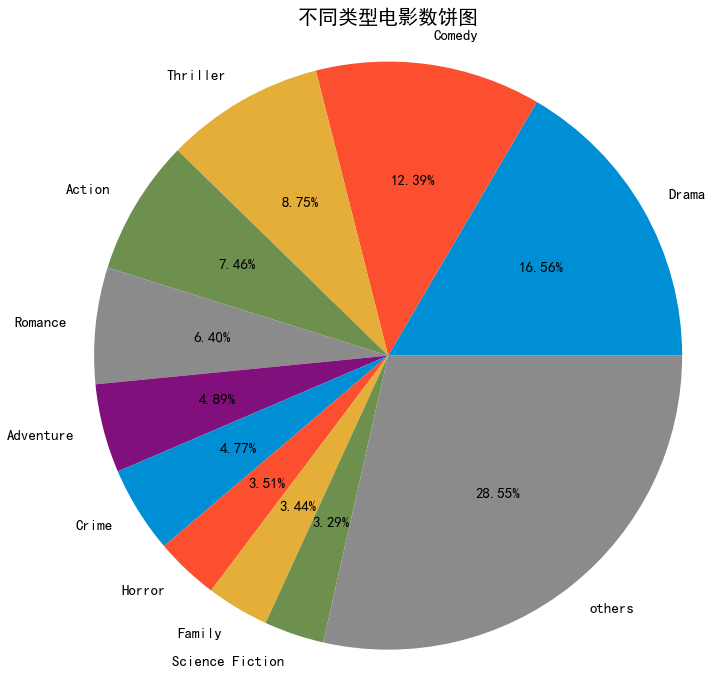

In [34]:
# 绘制不同类型电影数量图
# 定义饼图的大小
%matplotlib inline
warnings.filterwarnings('ignore')
plt.rcParams['font.sans-serif']=['SimHei']
plt.figure(figsize=(10, 12))
size = gdict.values()
labels = gdict.keys()
plt.pie(size, labels=labels, autopct = '%3.2f%%',startangle=0, textprops={'fontsize':15,'color':'black'})
plt.axis('equal')
plt.title('不同类型电影数饼图', fontsize=20)
plt.show()

In [1]:
from collections import Counter
from operator import itemgetter
from wordcloud import WordCloud 

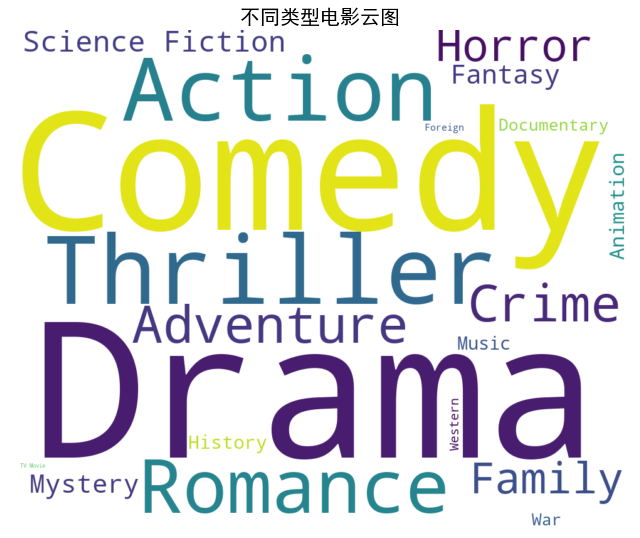

In [36]:
# 用云图展示
wc = WordCloud(background_color='white', width=1000, height=800, margin=2).generate_from_frequencies(dict(genres_year.sum()))
plt.figure(figsize=(10,15))
plt.imshow(wc,interpolation="bilinear")
plt.axis('off')
plt.title('不同类型电影云图', fontsize=20)
plt.show()

In [873]:
keyword_list=[]
list1=[]
for x in fullDF['keywords']:
    keyword_list.append(x)
    keyword_list
keyword_list=''.join(keyword_list)
keyword_list.replace('\'s','') 

'culture clash,future,space war,space colony,society,space travel,futuristic,romance,space,alien,tribe,alien planet,cgi,marine,soldier,battle,love affair,anti war,power relations,mind and soul,3docean,drug abuse,exotic island,east india trading company,love of one life,traitor,shipwreck,strong woman,ship,alliance,calypso,afterlife,fighter,pirate,swashbuckler,aftercreditsstingerspy,based on novel,secret agent,sequel,mi6,british secret service,united kingdomdc comics,crime fighter,terrorist,secret identity,burglar,hostage drama,time bomb,gotham city,vigilante,cover-up,superhero,villainess,tragic hero,terrorism,destruction,catwoman,cat burglar,imax,flood,criminal underworld,batmanbased on novel,mars,medallion,space travel,princess,alien,steampunk,martian,escape,edgar rice burroughs,alien race,superhuman strength,mars civilization,sword and planet,19th century,3ddual identity,amnesia,sandstorm,love of one life,forgiveness,spider,wretch,death of a friend,egomania,sand,narcism,hostility,marv

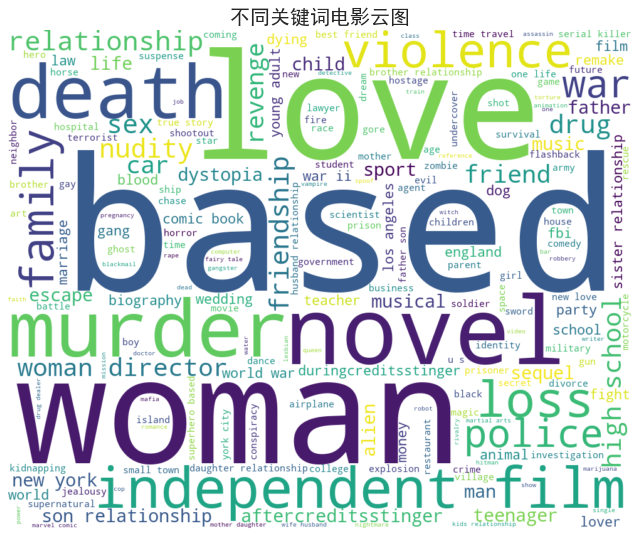

In [874]:
wc1 = WordCloud(background_color='white', width=1000, 
               height=800, margin=2).generate(keyword_list)
plt.figure(figsize=(10,15))
plt.imshow(wc1,interpolation="bilinear")
plt.axis('off')
plt.title('不同关键词电影云图', fontsize=20)
plt.show()

### 电影风格随时间是如何变化的?

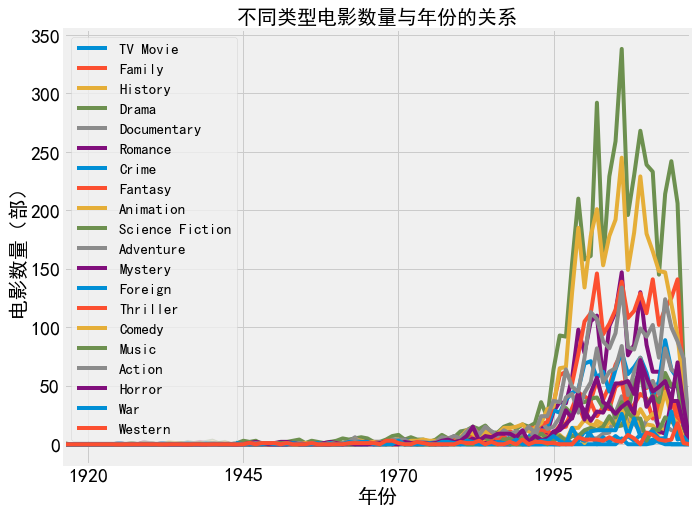

In [39]:
# 绘制电影类型随年代变化图
genres_year.plot(figsize=(10, 8), fontsize=20)
plt.xlabel('年份', fontsize=20)
plt.ylabel('电影数量（部）', fontsize=20)
plt.legend(loc=2, fontsize=15)
plt.title('不同类型电影数量与年份的关系', fontsize=20)
plt.show()

In [283]:
# create new movie dataframe with revenue/budget > 0
commercial_movie_filter = (fullDF.revenue > 0) & (fullDF.budget > 0)
commercial_movies = fullDF[commercial_movie_filter].copy()

# calculate profit
commercial_movies['profit'] = (commercial_movies.revenue - commercial_movies.budget) / commercial_movies.budget * 100

# view summary
commercial_movies.describe()

,budget,id,popularity,revenue,vote_average,vote_count,release_month,profit
count,4.803000e+03,4803.000000,4803.000000,4.803000e+03,4803.000000,4803.000000,4803.000000,4.803000e+03
mean,3.531606e+07,57165.484281,21.496775,1.067008e+08,6.172081,699.127736,6.796794,1.281839e+07
std,3.790514e+07,88694.614033,31.815138,1.546419e+08,0.966326,1232.060053,3.424368,3.013285e+08
min,1.000000e+00,5.000000,0.000372,5.000000e+00,0.500000,1.000000,1.000000,-9.999997e+01
25%,1.200000e+07,9014.500000,4.674558,2.760697e+07,5.600000,59.000000,4.000000,3.918084e+01
50%,2.904504e+07,14629.000000,12.928269,8.226064e+07,6.200000,250.000000,7.000000,1.832175e+02
75%,4.000000e+07,58610.500000,28.313505,9.291719e+07,6.800000,737.000000,10.000000,3.407279e+02
max,3.800000e+08,459488.000000,875.581305,2.787965e+09,10.000000,13752.000000,12.000000,8.226064e+09


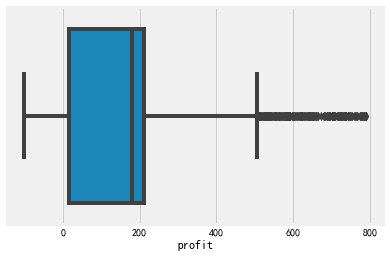

In [297]:
# define upper hinge, lower hinge and IQR values
profit_lower_hinge = commercial_movies.profit.quantile(0.25)
profit_upper_hinge = commercial_movies.profit.quantile(0.75)
profit_IQR = profit_upper_hinge - profit_lower_hinge

# filter outliers
profit_outlier_filter = (commercial_movies.profit >= profit_lower_hinge - 1.5 * profit_IQR) & (commercial_movies.profit <= profit_upper_hinge + 1.5 * profit_IQR)
cm_filtered = commercial_movies[profit_outlier_filter].copy()

sns.boxplot(x=cm_filtered.profit);

Lower budget movies have a mean profit margin of 170.25944138974373%.
Higher budget movies have a mean profit margin of 142.26648214863258%


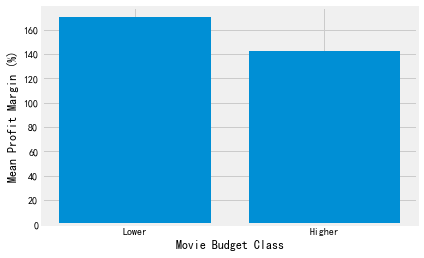

In [291]:
# define mean profit margin for each class
lower_budget_profit_margin = cm_filtered.query('budget <= @cm_filtered.budget.mean()').profit.mean()
higher_budget_profit_margin = cm_filtered.query('budget > @cm_filtered.budget.mean()').profit.mean()
print('Lower budget movies have a mean profit margin of {}%.'.format(lower_budget_profit_margin))
print('Higher budget movies have a mean profit margin of {}%'.format(higher_budget_profit_margin))
fig, ax = plt.subplots()
ax.bar(['Lower', 'Higher'], [lower_budget_profit_margin, higher_budget_profit_margin])
ax.set_xlabel('Movie Budget Class')
ax.set_ylabel('Mean Profit Margin (%)');

### 电影预算高低是否影响票房?

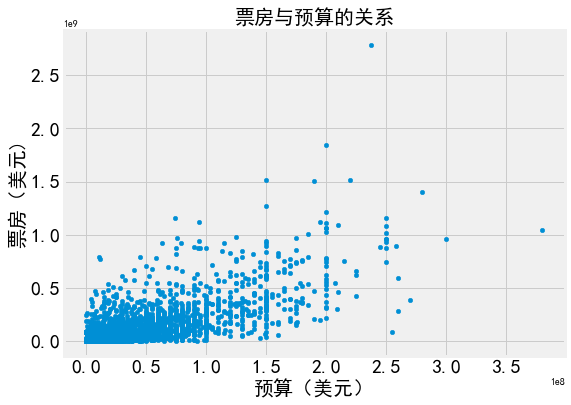

In [316]:
# 票房与预算的关系
fullDF.plot(kind='scatter', x='budget', y='revenue', figsize=(8, 6), fontsize=20)
plt.xlabel('预算（美元）', fontsize=20)
plt.ylabel('票房（美元)', fontsize=20)
plt.title('票房与预算的关系', fontsize=20)
plt.show()

### 高票房或者高评分的导演有哪些? 

In [25]:
json_cols = ['cast', 'crew'] 
for i in json_cols:
    fullDF[i] = fullDF[i].apply(json.loads) 

In [26]:
# 提取演员
def get_names(x):
    return ','.join([i['name'] for i in x])
fullDF['cast'] =  fullDF['cast'].apply(get_names)
fullDF.head() 

,budget,genres,id,keywords,original_language,original_title,popularity,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,title,vote_average,vote_count,cast,crew,release_year,release_month,release_day,release_dow
0,237000000.0,"Action,Adventure,Fantasy,Science Fiction",19995,"culture clash,future,space war,space colony,so...",en,Avatar,150.437577,"Ingenious Film Partners,Twentieth Century Fox ...","United States of America,United Kingdom",2009-12-10,2.787965e+09,162,"English,Español",Avatar,7.2,11800.0,"Sam Worthington,Zoe Saldana,Sigourney Weaver,S...","[{'credit_id': '52fe48009251416c750aca23', 'de...",2009,12,10,3
1,300000000.0,"Adventure,Fantasy,Action",285,"ocean,drug abuse,exotic island,east india trad...",en,Pirates of the Caribbean: At World's End,139.082615,"Walt Disney Pictures,Jerry Bruckheimer Films,S...",United States of America,2007-05-19,9.610000e+08,169,English,Pirates of the Caribbean: At World's End,6.9,4500.0,"Johnny Depp,Orlando Bloom,Keira Knightley,Stel...","[{'credit_id': '52fe4232c3a36847f800b579', 'de...",2007,5,19,5
2,245000000.0,"Action,Adventure,Crime",206647,"spy,based on novel,secret agent,sequel,mi6,bri...",en,Spectre,107.376788,"Columbia Pictures,Danjaq,B24","United Kingdom,United States of America",2015-10-26,8.806746e+08,148,"Français,English,Español,Italiano,Deutsch",Spectre,6.3,4466.0,"Daniel Craig,Christoph Waltz,Léa Seydoux,Ralph...","[{'credit_id': '54805967c3a36829b5002c41', 'de...",2015,10,26,0
3,250000000.0,"Action,Crime,Drama,Thriller",49026,"dc comics,crime fighter,terrorist,secret ident...",en,The Dark Knight Rises,112.312950,"Legendary Pictures,Warner Bros.,DC Entertainme...",United States of America,2012-07-16,1.084939e+09,165,English,The Dark Knight Rises,7.6,9106.0,"Christian Bale,Michael Caine,Gary Oldman,Anne ...","[{'credit_id': '52fe4781c3a36847f81398c3', 'de...",2012,7,16,0
4,260000000.0,"Action,Adventure,Science Fiction",49529,"based on novel,mars,medallion,space travel,pri...",en,John Carter,43.926995,Walt Disney Pictures,United States of America,2012-03-07,2.841391e+08,132,English,John Carter,6.1,2124.0,"Taylor Kitsch,Lynn Collins,Samantha Morton,Wil...","[{'credit_id': '52fe479ac3a36847f813eaa3', 'de...",2012,3,7,2


In [27]:
# 提取导演
def get_directors(x):
    for i in x:
        if i['job'] == 'Director':
            return i['name']
fullDF['crew'] = fullDF['crew'].apply(get_directors) 

In [28]:
#将字段‘crew’改为‘director’ 
fullDF.rename(columns={'crew':'director'}, inplace = True) 

In [29]:
fullDF['director'] 

0           James Cameron
1          Gore Verbinski
2              Sam Mendes
3       Christopher Nolan
4          Andrew Stanton
              ...        
4798     Robert Rodriguez
4799         Edward Burns
4800          Scott Smith
4801          Daniel Hsia
4802     Brian Herzlinger
Name: director, Length: 4803, dtype: object

In [30]:
dir = fullDF[['director','vote_average','revenue']]
dir 

,director,vote_average,revenue
0,James Cameron,7.2,2.787965e+09
1,Gore Verbinski,6.9,9.610000e+08
2,Sam Mendes,6.3,8.806746e+08
3,Christopher Nolan,7.6,1.084939e+09
4,Andrew Stanton,6.1,2.841391e+08
...,...,...,...
4798,Robert Rodriguez,6.6,2.040920e+06
4799,Edward Burns,5.9,8.226064e+07
4800,Scott Smith,7.0,8.226064e+07
4801,Daniel Hsia,5.7,8.226064e+07


In [31]:
# 高评分
dir1 =dir.sort_values(by='vote_average', ascending=False, na_position='first')
dir1

,director,vote_average,revenue
3519,Gary Sinyor,10.0,8.226064e+07
4247,None,10.0,8.226064e+07
4045,Tim McCanlies,10.0,5.655920e+05
4662,None,10.0,8.226064e+07
3992,Rohit Jugraj,9.5,8.226064e+07
...,...,...,...
4562,None,2.0,8.226064e+07
2220,Bob Clark,1.9,9.109322e+06
3689,Leonard Farlinger,1.0,8.226064e+07
4581,Sue Corcoran,1.0,8.226064e+07


In [32]:
# 高票房
dir2 =dir.sort_values(by='revenue', ascending=False, na_position='first')
dir2

,director,vote_average,revenue
0,James Cameron,7.2,2.787965e+09
25,James Cameron,7.5,1.845034e+09
16,Joss Whedon,7.4,1.519558e+09
28,Colin Trevorrow,6.5,1.513529e+09
44,James Wan,7.3,1.506249e+09
...,...,...,...
3131,Benedikt Erlingsson,6.9,1.100000e+01
3428,Louis Morneau,4.1,1.000000e+01
3419,Rachel Perkins,5.2,7.000000e+00
3875,Eric Styles,8.0,7.000000e+00


以下3人

Gary Sinyor

Tim McCanlies

James Cameron

### 电影的发行时间最好选在啥时候? 

Text(0.5, 1.0, 'Analysis of profit margin in relation to movie release month')

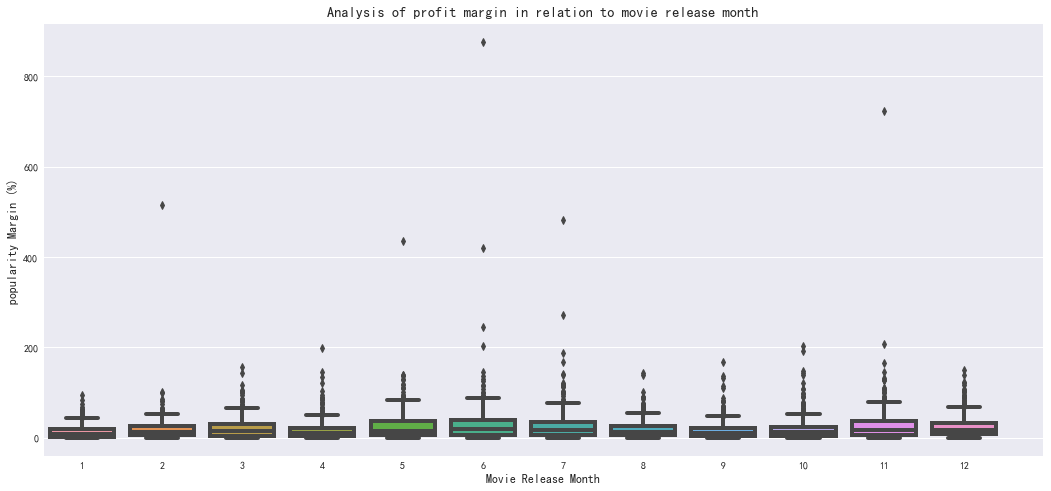

In [467]:
# distributions of popularity margin by release month
fig, ax = plt.subplots(figsize=(16,8))
# cm_filtered.boxplot(column=['profit'], by=['release_month'], ax=ax)
sns.boxplot(x='release_month', y='popularity', data=fullDF, ax=ax)
ax.set_xlabel('Movie Release Month')
ax.set_xticks(range(13))
ax.set_ylabel('popularity Margin (%)')
ax.set_title('Analysis of profit margin in relation to movie release month') 

In [469]:
Q1 = fullDF.quantile(0.25)
Q3 = fullDF.quantile(0.75)
IQR = Q3 - Q1
outliers = ((fullDF < (Q1 - 1.5 * IQR)) | (fullDF > (Q3 + 1.5 * IQR))).sum()
outliers[outliers>0]

budget          419
id              704
popularity      275
release_year    274
revenue         586
vote_average     93
vote_count      504
dtype: int64

AttributeError: 'DataFrame' object has no attribute 'show'

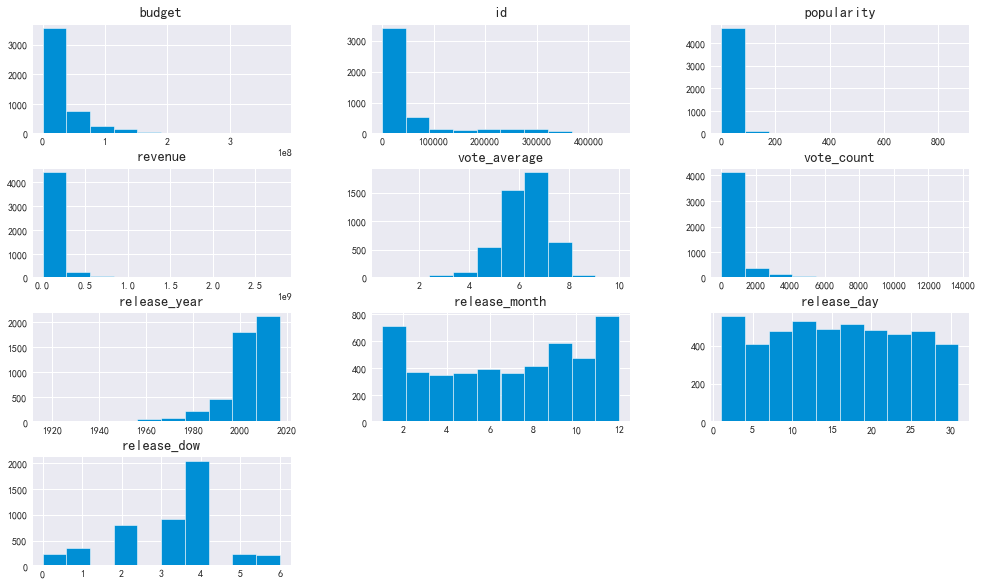

In [470]:
fullDF.hist(figsize=(15, 10))
fullDF.show() 

### 拍原创电影好还是改编电影好?

In [300]:
#原创电影与改编电影对比分析
original_novel = pd.DataFrame()
original_novel['keywords'] = commercial_movies['keywords'].str.contains('based on').map(lambda x: 1 if x else 0)
original_novel['popularity'] = commercial_movies['popularity']
novel_count = original_novel['keywords'].sum()
original_count = original_novel['keywords'].count() - original_novel['keywords'].sum()
original_novel = original_novel.groupby('keywords', as_index = False).mean()
#创建原创与改编对比的数据框
org_vs_novel = pd.DataFrame()
org_vs_novel['count'] = [original_count, novel_count]
org_vs_novel['popularity'] = original_novel['popularity']
org_vs_novel.index = ['original works', 'based_on_novel'] 

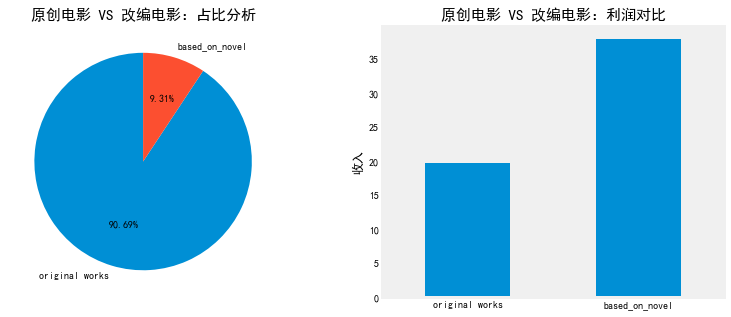

In [301]:
#可视化原创电影与改编电影的数量占比（饼图）、片均受益（柱状图）
fig= plt.figure(figsize = (12,5))
ax1 = plt.subplot(1, 2, 1)
ax1 = plt.pie(org_vs_novel['count'], labels=org_vs_novel.index, autopct='%.2f%%', startangle=90, pctdistance=0.6)
plt.title('原创电影 VS 改编电影：占比分析', fontsize=15)
ax2 = plt.subplot(1, 2, 2)
ax2 = org_vs_novel['popularity'].plot.bar()
plt.xticks(rotation=0)
plt.ylabel('收入', fontsize=12)
plt.title('原创电影 VS 改编电影：利润对比', fontsize=15)
plt.grid(False)
plt.show()

# 导入预测数据

In [33]:
pre = pd.read_csv('F:/大三（上）/机器学习/机器学习期末报告/机器学习期末报告/电影数据分析/data/tmdb_1000_predict.csv',encoding='utf-8')
pre.head()

,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,title,vote_average,vote_count
0,16000000,"[{""id"": 35, ""name"": ""Comedy""}, {""id"": 18, ""nam...",http://thewomen.warnerbros.com/index.html,13972,"[{""id"": 9749, ""name"": ""beauty salon""}, {""id"": ...",en,The Women,"The story centers on a group of gossipy, high-...",8.832100,"[{""name"": ""New Line Cinema"", ""id"": 12}]","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2008/9/12,50007546,114,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,NaN,The Women,NaN,NaN
1,15000000,"[{""id"": 18, ""name"": ""Drama""}, {""id"": 10749, ""n...",NaN,5038,"[{""id"": 107, ""name"": ""barcelona spain""}, {""id""...",en,Vicky Cristina Barcelona,Two girlfriends on a summer holiday in Spain b...,32.758254,"[{""name"": ""The Weinstein Company"", ""id"": 308},...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2008/8/15,96408652,96,"[{""iso_639_1"": ""es"", ""name"": ""Espa\u00f1ol""}, ...",Released,Life is the ultimate work of art,Vicky Cristina Barcelona,NaN,NaN
2,25000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",NaN,13491,"[{""id"": 156321, ""name"": ""tv movie""}]",sv,Arn: Tempelriddaren,"Arn, the son of a high-ranking Swedish noblema...",6.091033,"[{""name"": ""Danmarks Radio (DR)"", ""id"": 119}, {...","[{""iso_3166_1"": ""SE"", ""name"": ""Sweden""}]",2007/12/17,0,139,"[{""iso_639_1"": ""ar"", ""name"": ""\u0627\u0644\u06...",Released,A Knight in the Holy Land. A Woman in the Froz...,Arn: The Knight Templar,NaN,NaN
3,16000000,"[{""id"": 35, ""name"": ""Comedy""}, {""id"": 18, ""nam...",NaN,10571,"[{""id"": 815, ""name"": ""soulmates""}, {""id"": 1605...",en,Boys and Girls,Ryan and Jennifer are opposites who definitely...,9.119797,"[{""name"": ""Punch 21 Productions"", ""id"": 13158}]","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2000/6/16,20627372,94,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,Warning: Sex Changes Everything,Boys and Girls,NaN,NaN
4,0,"[{""id"": 18, ""name"": ""Drama""}]",NaN,10994,"[{""id"": 351, ""name"": ""poison""}, {""id"": 378, ""n...",en,White Oleander,A teenager journeys through a series of foster...,9.423866,"[{""name"": ""Pandora Filmproduktion"", ""id"": 254}...","[{""iso_3166_1"": ""DE"", ""name"": ""Germany""}, {""is...",2002/10/11,0,109,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,NaN,White Oleander,NaN,NaN


In [34]:
#json数据解析
json_cols = ['genres','keywords', 'spoken_languages', 'production_companies', 'production_countries']
for i in json_cols:
    pre[i] = pre[i].apply(json.loads)
def get_names(x):
    return ','.join([i['name'] for i in x])
pre['genres'] = pre['genres'].apply(get_names)
pre['keywords'] = pre['keywords'].apply(get_names)          
pre['spoken_languages'] = pre['spoken_languages'].apply(get_names)
pre['production_countries'] = pre['production_countries'].apply(get_names) 
pre['production_companies'] = pre['production_companies'].apply(get_names)

In [35]:
#deleted columns 
deleted_columns = ['vote_average','vote_count','homepage', 'tagline', 'overview','status']
#drop it from our pre
pre.drop(deleted_columns,axis = 1 ,inplace = True) 

In [36]:
pre.isnull().sum()  

budget                  0
genres                  0
id                      0
keywords                0
original_language       0
original_title          0
popularity              0
production_companies    0
production_countries    0
release_date            1
revenue                 0
runtime                 0
spoken_languages        0
title                   0
dtype: int64

In [37]:
nanX2=pre['release_date'].isnull()
pre.loc[nanX2,:] 

,budget,genres,id,keywords,original_language,original_title,popularity,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,title
989,0,,380097,,en,America Is Still the Place,0.0,,,NaN,0,0,,America Is Still the Place


In [38]:
pre.loc[989,'release_date']='2014/6/1'
pre.loc[nanX2,:]  

,budget,genres,id,keywords,original_language,original_title,popularity,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,title
989,0,,380097,,en,America Is Still the Place,0.0,,,2014/6/1,0,0,,America Is Still the Place


In [39]:
# 异常值处理
# 对预算、票房、受欢迎程度、评分、评分次数中为0的数值用平均值替代
pre['budget'].replace(0, pre['budget'].mean(), inplace=True)
pre['revenue'].replace(0, pre['revenue'].mean(), inplace=True)
pre['popularity'].replace(0, pre['popularity'].mean(), inplace=True)
pre.describe()  

,budget,id,popularity,revenue,runtime
count,1.000000e+03,1000.000000,1000.000000,1.000000e+03,1000.000000
mean,5.548203e+06,63166.587000,10.902972,2.369896e+07,102.484000
std,4.114293e+06,92898.556847,14.507062,4.261913e+07,21.892442
min,3.000000e+00,5.000000,0.000372,5.000000e+00,0.000000
25%,4.000000e+06,10337.000000,2.294844,1.173800e+07,91.000000
50%,4.159073e+06,19729.500000,6.070801,1.618781e+07,99.000000
75%,6.000000e+06,67985.250000,13.486736,1.618781e+07,110.000000
max,4.060000e+07,447027.000000,192.528841,7.929106e+08,240.000000


In [40]:
# 将release_date的数据类型转化成日期类型
pre.loc[:,'release_date']=pd.to_datetime(pre.loc[:,'release_date'],format='%Y-%m-%d',errors='coerce')
pre.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   budget                1000 non-null   float64       
 1   genres                1000 non-null   object        
 2   id                    1000 non-null   int64         
 3   keywords              1000 non-null   object        
 4   original_language     1000 non-null   object        
 5   original_title        1000 non-null   object        
 6   popularity            1000 non-null   float64       
 7   production_companies  1000 non-null   object        
 8   production_countries  1000 non-null   object        
 9   release_date          1000 non-null   datetime64[ns]
 10  revenue               1000 non-null   float64       
 11  runtime               1000 non-null   int64         
 12  spoken_languages      1000 non-null   object        
 13  title              

In [41]:
#pre['release_date'] = pre['release_date'].fillna('2000-01-01')
pre['release_year'] = pd.DatetimeIndex(pre['release_date']).year
pre['release_month'] = pd.DatetimeIndex(pre['release_date']).month
pre['release_day'] = pd.DatetimeIndex(pre['release_date']).day
pre['release_dow'] = pd.DatetimeIndex(pre['release_date']).dayofweek
pre = pre.drop('release_date', axis=1) 

In [42]:
Q1 = pre.quantile(0.25)
Q3 = pre.quantile(0.75)
IQR = Q3 - Q1
outliers = ((pre < (Q1 - 1.5 * IQR)) | (pre > (Q3 + 1.5 * IQR))).sum()
outliers[outliers>0]

budget          170
id              146
popularity       81
release_year     91
revenue         342
runtime          58
dtype: int64

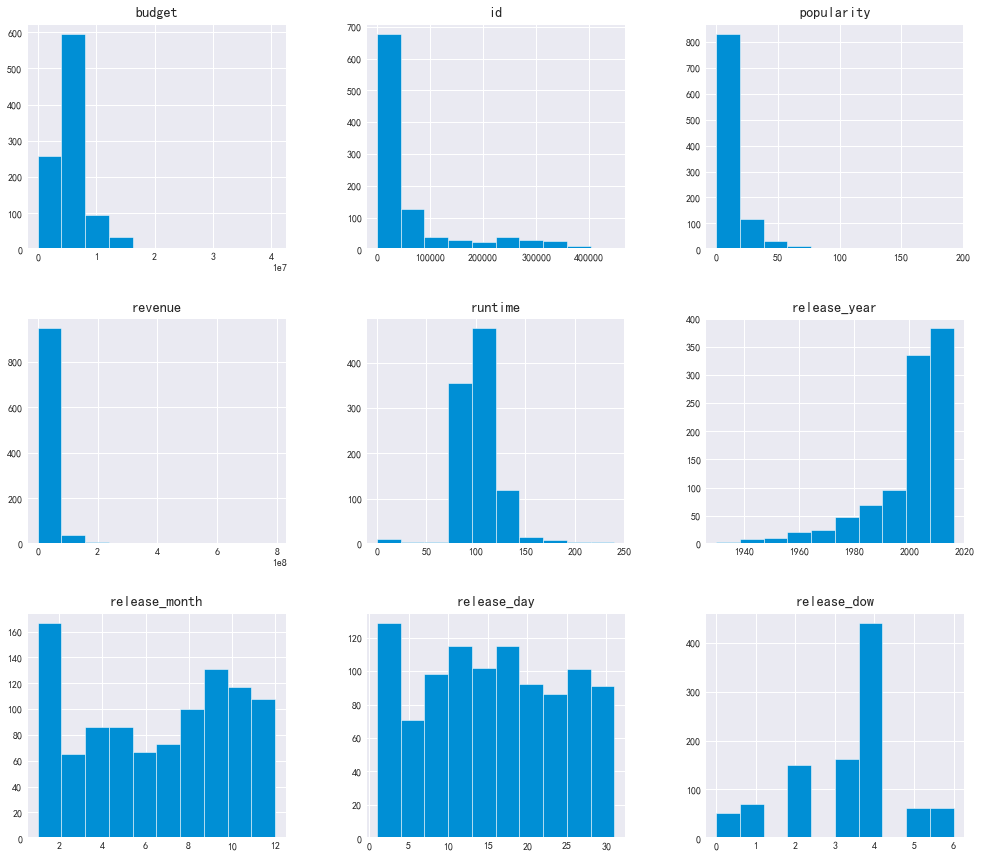

In [507]:
pre.hist(figsize=(15, 15))
plt.show() 

In [43]:
pre.head(n=2) 

,budget,genres,id,keywords,original_language,original_title,popularity,production_companies,production_countries,revenue,runtime,spoken_languages,title,release_year,release_month,release_day,release_dow
0,16000000.0,"Comedy,Drama,Romance",13972,"beauty salon,divorce,woman director",en,The Women,8.832100,New Line Cinema,United States of America,50007546.0,114,English,The Women,2008,9,12,4
1,15000000.0,"Drama,Romance",5038,"barcelona spain,menage a trois,author",en,Vicky Cristina Barcelona,32.758254,"The Weinstein Company,Gravier Productions,Ante...","United States of America,Spain",96408652.0,96,"Español,English",Vicky Cristina Barcelona,2008,8,15,4


# 特征提取&建立分类器

In [649]:
for i,j in zip(fullDF['genres'],fullDF.index):
    list2=[]
    list2=i 
    fullDF.loc[j,'genres']=str(list2)
fullDF['genres'] = fullDF['genres'].str.strip('[]').str.replace(' ','').str.replace("'",'')
fullDF['genres'] = fullDF['genres'].str.split(',') 

In [650]:
genreList = []
for index, row in fullDF.iterrows():
    genres = row["genres"]
    
    for genre in genres:
        if genre not in genreList:
            genreList.append(genre)
genreList[:10] 

['Action',
 'Adventure',
 'Fantasy',
 'ScienceFiction',
 'Crime',
 'Drama',
 'Thriller',
 'Animation',
 'Family',
 'Western']

In [651]:
# 独热编码
def binary(genre_list):
    binaryList = []
    
    for genre in genreList:
        if genre in genre_list:
            binaryList.append(1)
        else:
            binaryList.append(0)
    
    return binaryList

In [652]:
fullDF['genres_bin'] = fullDF['genres'].apply(lambda x: binary(x))
fullDF['genres_bin'].head()

0    [1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...
1    [1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...
2    [1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...
3    [1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, ...
4    [1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...
Name: genres_bin, dtype: object

In [653]:
for i,j in zip(fullDF['cast'],fullDF.index):
    list2 = []
    list2 = i[:4]
    fullDF.loc[j,'cast'] = str(list2)
fullDF['cast'] = fullDF['cast'].str.strip('[]').str.replace(' ','').str.replace("'",'')
fullDF['cast'] = fullDF['cast'].str.split(',')
for i,j in zip(fullDF['cast'],fullDF.index):
    list2 = []
    list2 = i
    fullDF.loc[j,'cast'] = str(list2)
fullDF['cast']=fullDF['cast'].str.strip('[]').str.replace(' ','').str.replace("'",'')

In [654]:
castList = []
for index, row in fullDF.iterrows():
    cast = row["cast"]
    
    for i in cast:
        if i not in castList:
            castList.append(i) 

In [655]:
def binary(cast_list):
    binaryList = []
    
    for genre in castList:
        if genre in cast_list:
            binaryList.append(1)
        else:
            binaryList.append(0)
    
    return binaryList

In [656]:
fullDF['cast_bin'] = fullDF['cast'].apply(lambda x: binary(x))
fullDF['cast_bin'].head() 

0    [1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...
1    [0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, ...
2    [0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, ...
3    [0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, ...
4    [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, ...
Name: cast_bin, dtype: object

In [657]:
def xstr(s):
    if s is None:
        return ''
    return str(s)
fullDF['director'] = fullDF['director'].apply(xstr) 

In [658]:
directorList=[]
for i in fullDF['director']:
    if i not in directorList:
        directorList.append(i) 

In [659]:
def binary(director_list):
    binaryList = []  
    for direct in directorList:
        if direct in director_list:
            binaryList.append(1)
        else:
            binaryList.append(0)
    return binaryList

In [660]:
fullDF['director_bin'] = fullDF['director'].apply(lambda x: binary(x))
fullDF.head()

,budget,genres,id,keywords,original_language,original_title,popularity,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,title,vote_average,vote_count,cast,director,release_year,release_month,release_day,release_dow,genres_bin,cast_bin,director_bin
0,237000000.0,"[Action, Adventure, Fantasy, ScienceFiction]",19995,"culture clash,future,space war,space colony,so...",en,Avatar,150.437577,"Ingenious Film Partners,Twentieth Century Fox ...","United States of America,United Kingdom",2009-12-10,2.787965e+09,162,"English,Español",Avatar,7.2,11800.0,Sam,James Cameron,2009,12,10,3,"[1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
1,300000000.0,"[Adventure, Fantasy, Action]",285,"ocean,drug abuse,exotic island,east india trad...",en,Pirates of the Caribbean: At World's End,139.082615,"Walt Disney Pictures,Jerry Bruckheimer Films,S...",United States of America,2007-05-19,9.610000e+08,169,English,Pirates of the Caribbean: At World's End,6.9,4500.0,John,Gore Verbinski,2007,5,19,5,"[1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
2,245000000.0,"[Action, Adventure, Crime]",206647,"spy,based on novel,secret agent,sequel,mi6,bri...",en,Spectre,107.376788,"Columbia Pictures,Danjaq,B24","United Kingdom,United States of America",2015-10-26,8.806746e+08,148,"Français,English,Español,Italiano,Deutsch",Spectre,6.3,4466.0,Dani,Sam Mendes,2015,10,26,0,"[1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, ...","[0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
3,250000000.0,"[Action, Crime, Drama, Thriller]",49026,"dc comics,crime fighter,terrorist,secret ident...",en,The Dark Knight Rises,112.312950,"Legendary Pictures,Warner Bros.,DC Entertainme...",United States of America,2012-07-16,1.084939e+09,165,English,The Dark Knight Rises,7.6,9106.0,Chri,Christopher Nolan,2012,7,16,0,"[1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, ...","[0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
4,260000000.0,"[Action, Adventure, ScienceFiction]",49529,"based on novel,mars,medallion,space travel,pri...",en,John Carter,43.926995,Walt Disney Pictures,United States of America,2012-03-07,2.841391e+08,132,English,John Carter,6.1,2124.0,Tayl,Andrew Stanton,2012,3,7,2,"[1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, ...","[0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."


In [661]:
fullDF['keywords'] = fullDF['keywords'].str.strip('[]').str.replace(' ','').str.replace("'",'').str.replace('"','')
fullDF['keywords'] = fullDF['keywords'].str.split(',')
for i,j in zip(fullDF['keywords'],fullDF.index):
    list2 = []
    list2 = i
    fullDF.loc[j,'keywords'] = str(list2)
fullDF['keywords'] = fullDF['keywords'].str.strip('[]').str.replace(' ','').str.replace("'",'')
fullDF['keywords'] = fullDF['keywords'].str.split(',')
for i,j in zip(fullDF['keywords'],fullDF.index):
    list2 = [] 
    list2 = i
    list2.sort()
    fullDF.loc[j,'keywords'] = str(list2)
fullDF['keywords'] = fullDF['keywords'].str.strip('[]').str.replace(' ','').str.replace("'",'')
fullDF['keywords'] = fullDF['keywords'].str.split(',')

In [662]:
words_list = []
for index, row in fullDF.iterrows():
    genres = row["keywords"]
    
    for genre in genres:
        if genre not in words_list:
            words_list.append(genre) 

In [663]:
def binary(words):
    binaryList = []
    for genre in words_list:
        if genre in words:
            binaryList.append(1)
        else:
            binaryList.append(0)
    return binaryList

In [664]:
fullDF['words_bin'] = fullDF['keywords'].apply(lambda x: binary(x))
fullDF = fullDF[(fullDF['vote_average']!=0)] #removing the fullDF with 0 score and without drector names 
fullDF = fullDF[fullDF['director']!=''] 

In [665]:
fullDF.head()  

,budget,genres,id,keywords,original_language,original_title,popularity,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,title,vote_average,vote_count,cast,director,release_year,release_month,release_day,release_dow,genres_bin,cast_bin,director_bin,words_bin
0,237000000.0,"[Action, Adventure, Fantasy, ScienceFiction]",19995,"[3d, alien, alienplanet, antiwar, battle, cgi,...",en,Avatar,150.437577,"Ingenious Film Partners,Twentieth Century Fox ...","United States of America,United Kingdom",2009-12-10,2.787965e+09,162,"English,Español",Avatar,7.2,11800.0,Sam,James Cameron,2009,12,10,3,"[1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."
1,300000000.0,"[Adventure, Fantasy, Action]",285,"[aftercreditsstinger, afterlife, alliance, cal...",en,Pirates of the Caribbean: At World's End,139.082615,"Walt Disney Pictures,Jerry Bruckheimer Films,S...",United States of America,2007-05-19,9.610000e+08,169,English,Pirates of the Caribbean: At World's End,6.9,4500.0,John,Gore Verbinski,2007,5,19,5,"[1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
2,245000000.0,"[Action, Adventure, Crime]",206647,"[basedonnovel, britishsecretservice, mi6, secr...",en,Spectre,107.376788,"Columbia Pictures,Danjaq,B24","United Kingdom,United States of America",2015-10-26,8.806746e+08,148,"Français,English,Español,Italiano,Deutsch",Spectre,6.3,4466.0,Dani,Sam Mendes,2015,10,26,0,"[1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, ...","[0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
3,250000000.0,"[Action, Crime, Drama, Thriller]",49026,"[batman, burglar, catburglar, catwoman, cover-...",en,The Dark Knight Rises,112.312950,"Legendary Pictures,Warner Bros.,DC Entertainme...",United States of America,2012-07-16,1.084939e+09,165,English,The Dark Knight Rises,7.6,9106.0,Chri,Christopher Nolan,2012,7,16,0,"[1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, ...","[0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
4,260000000.0,"[Action, Adventure, ScienceFiction]",49529,"[19thcentury, 3d, alien, alienrace, basedonnov...",en,John Carter,43.926995,Walt Disney Pictures,United States of America,2012-03-07,2.841391e+08,132,English,John Carter,6.1,2124.0,Tayl,Andrew Stanton,2012,3,7,2,"[1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, ...","[0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."


In [666]:
# 分类预测器
new_id = list(range(0,fullDF.shape[0]))
fullDF['new_id']=new_id
fullDF=fullDF[['original_title','genres','vote_average','genres_bin','cast_bin','new_id','director','director_bin','words_bin']]
fullDF.head() 

,original_title,genres,vote_average,genres_bin,cast_bin,new_id,director,director_bin,words_bin
0,Avatar,"[Action, Adventure, Fantasy, ScienceFiction]",7.2,"[1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",0,James Cameron,"[1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."
1,Pirates of the Caribbean: At World's End,"[Adventure, Fantasy, Action]",6.9,"[1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, ...",1,Gore Verbinski,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
2,Spectre,"[Action, Adventure, Crime]",6.3,"[1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, ...",2,Sam Mendes,"[0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
3,The Dark Knight Rises,"[Action, Crime, Drama, Thriller]",7.6,"[1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, ...",3,Christopher Nolan,"[0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
4,John Carter,"[Action, Adventure, ScienceFiction]",6.1,"[1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, ...",4,Andrew Stanton,"[0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."


In [670]:
from scipy import spatial

def Similarity(movieId1, movieId2):
    a = fullDF.iloc[movieId1]
    b = fullDF.iloc[movieId2]
    
    genresA = a['genres_bin']
    genresB = b['genres_bin']
    
    genreDistance = spatial.distance.cosine(genresA, genresB)
    
    scoreA = a['cast_bin']
    scoreB = b['cast_bin']
    scoreDistance = spatial.distance.cosine(scoreA, scoreB)
    
    directA = a['director_bin']
    directB = b['director_bin']
    directDistance = spatial.distance.cosine(directA, directB)
    
    wordsA = a['words_bin']
    wordsB = b['words_bin']
    wordsDistance = spatial.distance.cosine(directA, directB)
    return genreDistance + directDistance + scoreDistance + wordsDistance

In [671]:
Similarity(3,160)  

2.7958758547680684

In [673]:
print(fullDF.iloc[3])
print(fullDF.iloc[160]) 

original_title                                The Dark Knight Rises
genres                             [Action, Crime, Drama, Thriller]
vote_average                                                    7.6
genres_bin        [1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, ...
cast_bin          [0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, ...
new_id                                                            3
director                                          Christopher Nolan
director_bin      [0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...
words_bin         [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...
Name: 3, dtype: object
original_title                           How to Train Your Dragon 2
genres            [Fantasy, Action, Adventure, Animation, Comedy...
vote_average                                                    7.6
genres_bin        [1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, ...
cast_bin          [0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, ...
new_id                   

In [674]:
new_id = list(range(0,fullDF.shape[0]))
fullDF['new_id']=new_id
fullDF=fullDF[['original_title','genres','vote_average','genres_bin','cast_bin','new_id','director','director_bin','words_bin']]
fullDF.head() 

,original_title,genres,vote_average,genres_bin,cast_bin,new_id,director,director_bin,words_bin
0,Avatar,"[Action, Adventure, Fantasy, ScienceFiction]",7.2,"[1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",0,James Cameron,"[1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."
1,Pirates of the Caribbean: At World's End,"[Adventure, Fantasy, Action]",6.9,"[1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, ...",1,Gore Verbinski,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
2,Spectre,"[Action, Adventure, Crime]",6.3,"[1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, ...",2,Sam Mendes,"[0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
3,The Dark Knight Rises,"[Action, Crime, Drama, Thriller]",7.6,"[1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, ...",3,Christopher Nolan,"[0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
4,John Carter,"[Action, Adventure, ScienceFiction]",6.1,"[1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, ...",4,Andrew Stanton,"[0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."


In [675]:
import operator

def predict_score(name):
    #name = input('Enter a movie title: ')
    new_movie = fullDF[fullDF['original_title'].str.contains(name)].iloc[0].to_frame().T
    print('Selected Movie: ',new_movie.original_title.values[0])
    def getNeighbors(baseMovie, K):
        distances = []
    
        for index, movie in fullDF.iterrows():
            if movie['new_id'] != baseMovie['new_id'].values[0]:
                dist = Similarity(baseMovie['new_id'].values[0], movie['new_id'])
                distances.append((movie['new_id'], dist))
    
        distances.sort(key=operator.itemgetter(1))
        neighbors = []
    
        for x in range(K):
            neighbors.append(distances[x])
        return neighbors

    K = 10
    avgRating = 0
    neighbors = getNeighbors(new_movie, K)
    
    print('\nRecommended Movies: \n')
    for neighbor in neighbors:
        avgRating = avgRating+fullDF.iloc[neighbor[0]][2]  
        print( fullDF.iloc[neighbor[0]][0]+" | Genres: "+str(fullDF.iloc[neighbor[0]][1]).strip('[]').replace(' ','')+" | Rating: "+str(movies.iloc[neighbor[0]][2]))
    
    print('\n')
    avgRating = avgRating/K
    print('The predicted rating for %s is: %f' %(new_movie['original_title'].values[0],avgRating))
    print('The actual rating for %s is %f' %(new_movie['original_title'].values[0],new_movie['vote_average']))

In [676]:
predict_score('Godfather')   

Selected Movie:  The Godfather: Part III

Recommended Movies: 

The Godfather | Genres: 'Drama','Crime' | Rating: 238
The Rainmaker | Genres: 'Drama','Crime','Thriller' | Rating: 11975
Scarface | Genres: 'Action','Crime','Drama','Thriller' | Rating: 111
The Insider | Genres: 'Drama','Thriller' | Rating: 9008
City Hall | Genres: 'Drama','Thriller' | Rating: 11062
People I Know | Genres: 'Drama','Thriller' | Rating: 11458
The Outsiders | Genres: 'Crime','Drama' | Rating: 227
Insomnia | Genres: 'Crime','Mystery','Thriller' | Rating: 320
88 Minutes | Genres: 'Crime','Mystery','Thriller' | Rating: 3489
Sea of Love | Genres: 'Drama','Crime','Mystery' | Rating: 12150


The predicted rating for The Godfather: Part III is: 6.800000
The actual rating for The Godfather: Part III is 7.100000


In [677]:
train_df = fullDF.iloc[:,6:].reset_index(drop=True)
train_df.head()

,director,director_bin,words_bin
0,James Cameron,"[1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."
1,Gore Verbinski,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
2,Sam Mendes,"[0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
3,Christopher Nolan,"[0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
4,Andrew Stanton,"[0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."


# 因子分析 

In [44]:
fullDF.head()  

,budget,genres,id,keywords,original_language,original_title,popularity,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,title,vote_average,vote_count,cast,director,release_year,release_month,release_day,release_dow
0,237000000.0,"Action,Adventure,Fantasy,Science Fiction",19995,"culture clash,future,space war,space colony,so...",en,Avatar,150.437577,"Ingenious Film Partners,Twentieth Century Fox ...","United States of America,United Kingdom",2009-12-10,2.787965e+09,162,"English,Español",Avatar,7.2,11800.0,"Sam Worthington,Zoe Saldana,Sigourney Weaver,S...",James Cameron,2009,12,10,3
1,300000000.0,"Adventure,Fantasy,Action",285,"ocean,drug abuse,exotic island,east india trad...",en,Pirates of the Caribbean: At World's End,139.082615,"Walt Disney Pictures,Jerry Bruckheimer Films,S...",United States of America,2007-05-19,9.610000e+08,169,English,Pirates of the Caribbean: At World's End,6.9,4500.0,"Johnny Depp,Orlando Bloom,Keira Knightley,Stel...",Gore Verbinski,2007,5,19,5
2,245000000.0,"Action,Adventure,Crime",206647,"spy,based on novel,secret agent,sequel,mi6,bri...",en,Spectre,107.376788,"Columbia Pictures,Danjaq,B24","United Kingdom,United States of America",2015-10-26,8.806746e+08,148,"Français,English,Español,Italiano,Deutsch",Spectre,6.3,4466.0,"Daniel Craig,Christoph Waltz,Léa Seydoux,Ralph...",Sam Mendes,2015,10,26,0
3,250000000.0,"Action,Crime,Drama,Thriller",49026,"dc comics,crime fighter,terrorist,secret ident...",en,The Dark Knight Rises,112.312950,"Legendary Pictures,Warner Bros.,DC Entertainme...",United States of America,2012-07-16,1.084939e+09,165,English,The Dark Knight Rises,7.6,9106.0,"Christian Bale,Michael Caine,Gary Oldman,Anne ...",Christopher Nolan,2012,7,16,0
4,260000000.0,"Action,Adventure,Science Fiction",49529,"based on novel,mars,medallion,space travel,pri...",en,John Carter,43.926995,Walt Disney Pictures,United States of America,2012-03-07,2.841391e+08,132,English,John Carter,6.1,2124.0,"Taylor Kitsch,Lynn Collins,Samantha Morton,Wil...",Andrew Stanton,2012,3,7,2


In [45]:
train= fullDF[['budget','genres','keywords','original_language','original_title',
               'popularity','production_companies','production_countries', 
               'revenue', 'runtime','release_year','spoken_languages','title',
               'release_month','release_day','release_dow','vote_average']]
train.head()  

,budget,genres,keywords,original_language,original_title,popularity,production_companies,production_countries,revenue,runtime,release_year,spoken_languages,title,release_month,release_day,release_dow,vote_average
0,237000000.0,"Action,Adventure,Fantasy,Science Fiction","culture clash,future,space war,space colony,so...",en,Avatar,150.437577,"Ingenious Film Partners,Twentieth Century Fox ...","United States of America,United Kingdom",2.787965e+09,162,2009,"English,Español",Avatar,12,10,3,7.2
1,300000000.0,"Adventure,Fantasy,Action","ocean,drug abuse,exotic island,east india trad...",en,Pirates of the Caribbean: At World's End,139.082615,"Walt Disney Pictures,Jerry Bruckheimer Films,S...",United States of America,9.610000e+08,169,2007,English,Pirates of the Caribbean: At World's End,5,19,5,6.9
2,245000000.0,"Action,Adventure,Crime","spy,based on novel,secret agent,sequel,mi6,bri...",en,Spectre,107.376788,"Columbia Pictures,Danjaq,B24","United Kingdom,United States of America",8.806746e+08,148,2015,"Français,English,Español,Italiano,Deutsch",Spectre,10,26,0,6.3
3,250000000.0,"Action,Crime,Drama,Thriller","dc comics,crime fighter,terrorist,secret ident...",en,The Dark Knight Rises,112.312950,"Legendary Pictures,Warner Bros.,DC Entertainme...",United States of America,1.084939e+09,165,2012,English,The Dark Knight Rises,7,16,0,7.6
4,260000000.0,"Action,Adventure,Science Fiction","based on novel,mars,medallion,space travel,pri...",en,John Carter,43.926995,Walt Disney Pictures,United States of America,2.841391e+08,132,2012,English,John Carter,3,7,2,6.1


In [46]:
train1 = train['genres'].str.split(',',0,expand=True)
train1[0]  

0            Action
1         Adventure
2            Action
3            Action
4            Action
           ...     
4798         Action
4799         Comedy
4800         Comedy
4801               
4802    Documentary
Name: 0, Length: 4803, dtype: object

In [47]:
train['genres']=train1[0]
train.head() 

,budget,genres,keywords,original_language,original_title,popularity,production_companies,production_countries,revenue,runtime,release_year,spoken_languages,title,release_month,release_day,release_dow,vote_average
0,237000000.0,Action,"culture clash,future,space war,space colony,so...",en,Avatar,150.437577,"Ingenious Film Partners,Twentieth Century Fox ...","United States of America,United Kingdom",2.787965e+09,162,2009,"English,Español",Avatar,12,10,3,7.2
1,300000000.0,Adventure,"ocean,drug abuse,exotic island,east india trad...",en,Pirates of the Caribbean: At World's End,139.082615,"Walt Disney Pictures,Jerry Bruckheimer Films,S...",United States of America,9.610000e+08,169,2007,English,Pirates of the Caribbean: At World's End,5,19,5,6.9
2,245000000.0,Action,"spy,based on novel,secret agent,sequel,mi6,bri...",en,Spectre,107.376788,"Columbia Pictures,Danjaq,B24","United Kingdom,United States of America",8.806746e+08,148,2015,"Français,English,Español,Italiano,Deutsch",Spectre,10,26,0,6.3
3,250000000.0,Action,"dc comics,crime fighter,terrorist,secret ident...",en,The Dark Knight Rises,112.312950,"Legendary Pictures,Warner Bros.,DC Entertainme...",United States of America,1.084939e+09,165,2012,English,The Dark Knight Rises,7,16,0,7.6
4,260000000.0,Action,"based on novel,mars,medallion,space travel,pri...",en,John Carter,43.926995,Walt Disney Pictures,United States of America,2.841391e+08,132,2012,English,John Carter,3,7,2,6.1


In [48]:
train2 = train['keywords'].str.split(',',0,expand=True)
train2[0]  

0                      culture clash
1                              ocean
2                                spy
3                          dc comics
4                     based on novel
                    ...             
4798    united states–mexico barrier
4799                                
4800                            date
4801                                
4802                       obsession
Name: 0, Length: 4803, dtype: object

In [49]:
train['keywords']=train2[0]
train.head()   

,budget,genres,keywords,original_language,original_title,popularity,production_companies,production_countries,revenue,runtime,release_year,spoken_languages,title,release_month,release_day,release_dow,vote_average
0,237000000.0,Action,culture clash,en,Avatar,150.437577,"Ingenious Film Partners,Twentieth Century Fox ...","United States of America,United Kingdom",2.787965e+09,162,2009,"English,Español",Avatar,12,10,3,7.2
1,300000000.0,Adventure,ocean,en,Pirates of the Caribbean: At World's End,139.082615,"Walt Disney Pictures,Jerry Bruckheimer Films,S...",United States of America,9.610000e+08,169,2007,English,Pirates of the Caribbean: At World's End,5,19,5,6.9
2,245000000.0,Action,spy,en,Spectre,107.376788,"Columbia Pictures,Danjaq,B24","United Kingdom,United States of America",8.806746e+08,148,2015,"Français,English,Español,Italiano,Deutsch",Spectre,10,26,0,6.3
3,250000000.0,Action,dc comics,en,The Dark Knight Rises,112.312950,"Legendary Pictures,Warner Bros.,DC Entertainme...",United States of America,1.084939e+09,165,2012,English,The Dark Knight Rises,7,16,0,7.6
4,260000000.0,Action,based on novel,en,John Carter,43.926995,Walt Disney Pictures,United States of America,2.841391e+08,132,2012,English,John Carter,3,7,2,6.1


In [50]:
train3 = train['production_companies'].str.split(',',0,expand=True)
train3[0]  

0        Ingenious Film Partners
1           Walt Disney Pictures
2              Columbia Pictures
3             Legendary Pictures
4           Walt Disney Pictures
                  ...           
4798           Columbia Pictures
4799                            
4800       Front Street Pictures
4801                            
4802    rusty bear entertainment
Name: 0, Length: 4803, dtype: object

In [51]:
train['production_companies']=train3[0]
train.head()   

,budget,genres,keywords,original_language,original_title,popularity,production_companies,production_countries,revenue,runtime,release_year,spoken_languages,title,release_month,release_day,release_dow,vote_average
0,237000000.0,Action,culture clash,en,Avatar,150.437577,Ingenious Film Partners,"United States of America,United Kingdom",2.787965e+09,162,2009,"English,Español",Avatar,12,10,3,7.2
1,300000000.0,Adventure,ocean,en,Pirates of the Caribbean: At World's End,139.082615,Walt Disney Pictures,United States of America,9.610000e+08,169,2007,English,Pirates of the Caribbean: At World's End,5,19,5,6.9
2,245000000.0,Action,spy,en,Spectre,107.376788,Columbia Pictures,"United Kingdom,United States of America",8.806746e+08,148,2015,"Français,English,Español,Italiano,Deutsch",Spectre,10,26,0,6.3
3,250000000.0,Action,dc comics,en,The Dark Knight Rises,112.312950,Legendary Pictures,United States of America,1.084939e+09,165,2012,English,The Dark Knight Rises,7,16,0,7.6
4,260000000.0,Action,based on novel,en,John Carter,43.926995,Walt Disney Pictures,United States of America,2.841391e+08,132,2012,English,John Carter,3,7,2,6.1


In [52]:
train4 = train['production_countries'].str.split(',',0,expand=True)
train4[0] 

0       United States of America
1       United States of America
2                 United Kingdom
3       United States of America
4       United States of America
                  ...           
4798                      Mexico
4799                            
4800    United States of America
4801    United States of America
4802    United States of America
Name: 0, Length: 4803, dtype: object

In [53]:
train['production_countries']=train4[0]
train.head()   

,budget,genres,keywords,original_language,original_title,popularity,production_companies,production_countries,revenue,runtime,release_year,spoken_languages,title,release_month,release_day,release_dow,vote_average
0,237000000.0,Action,culture clash,en,Avatar,150.437577,Ingenious Film Partners,United States of America,2.787965e+09,162,2009,"English,Español",Avatar,12,10,3,7.2
1,300000000.0,Adventure,ocean,en,Pirates of the Caribbean: At World's End,139.082615,Walt Disney Pictures,United States of America,9.610000e+08,169,2007,English,Pirates of the Caribbean: At World's End,5,19,5,6.9
2,245000000.0,Action,spy,en,Spectre,107.376788,Columbia Pictures,United Kingdom,8.806746e+08,148,2015,"Français,English,Español,Italiano,Deutsch",Spectre,10,26,0,6.3
3,250000000.0,Action,dc comics,en,The Dark Knight Rises,112.312950,Legendary Pictures,United States of America,1.084939e+09,165,2012,English,The Dark Knight Rises,7,16,0,7.6
4,260000000.0,Action,based on novel,en,John Carter,43.926995,Walt Disney Pictures,United States of America,2.841391e+08,132,2012,English,John Carter,3,7,2,6.1


In [54]:
train5 = train['spoken_languages'].str.split(',',0,expand=True)
train5[0] 

0        English
1        English
2       Français
3        English
4        English
          ...   
4798     Español
4799            
4800     English
4801     English
4802     English
Name: 0, Length: 4803, dtype: object

In [55]:
train['spoken_languages']=train5[0]
train.head()   

,budget,genres,keywords,original_language,original_title,popularity,production_companies,production_countries,revenue,runtime,release_year,spoken_languages,title,release_month,release_day,release_dow,vote_average
0,237000000.0,Action,culture clash,en,Avatar,150.437577,Ingenious Film Partners,United States of America,2.787965e+09,162,2009,English,Avatar,12,10,3,7.2
1,300000000.0,Adventure,ocean,en,Pirates of the Caribbean: At World's End,139.082615,Walt Disney Pictures,United States of America,9.610000e+08,169,2007,English,Pirates of the Caribbean: At World's End,5,19,5,6.9
2,245000000.0,Action,spy,en,Spectre,107.376788,Columbia Pictures,United Kingdom,8.806746e+08,148,2015,Français,Spectre,10,26,0,6.3
3,250000000.0,Action,dc comics,en,The Dark Knight Rises,112.312950,Legendary Pictures,United States of America,1.084939e+09,165,2012,English,The Dark Knight Rises,7,16,0,7.6
4,260000000.0,Action,based on novel,en,John Carter,43.926995,Walt Disney Pictures,United States of America,2.841391e+08,132,2012,English,John Carter,3,7,2,6.1


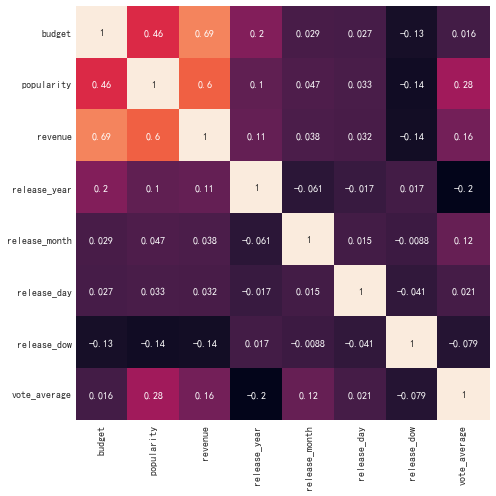

In [715]:
plt.figure(figsize=(12, 7))
corr_matrix = train .corr()
sns.heatmap(corr_matrix, mask=np.zeros_like(corr_matrix, dtype=np.bool), square=True, annot=True, cbar=False)
plt.tight_layout()

In [716]:
corr_matrix['vote_average'].sort_values(ascending=False)

vote_average     1.000000
popularity       0.283175
revenue          0.158390
release_month    0.116930
release_day      0.020570
budget           0.015722
release_dow     -0.079236
release_year    -0.196502
Name: vote_average, dtype: float64

# 模型建立

In [56]:
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, PowerTransformer, MultiLabelBinarizer

In [57]:
fullDF2  = train[train ['vote_average']!=0]
fullDF2.head()  

,budget,genres,keywords,original_language,original_title,popularity,production_companies,production_countries,revenue,runtime,release_year,spoken_languages,title,release_month,release_day,release_dow,vote_average
0,237000000.0,Action,culture clash,en,Avatar,150.437577,Ingenious Film Partners,United States of America,2.787965e+09,162,2009,English,Avatar,12,10,3,7.2
1,300000000.0,Adventure,ocean,en,Pirates of the Caribbean: At World's End,139.082615,Walt Disney Pictures,United States of America,9.610000e+08,169,2007,English,Pirates of the Caribbean: At World's End,5,19,5,6.9
2,245000000.0,Action,spy,en,Spectre,107.376788,Columbia Pictures,United Kingdom,8.806746e+08,148,2015,Français,Spectre,10,26,0,6.3
3,250000000.0,Action,dc comics,en,The Dark Knight Rises,112.312950,Legendary Pictures,United States of America,1.084939e+09,165,2012,English,The Dark Knight Rises,7,16,0,7.6
4,260000000.0,Action,based on novel,en,John Carter,43.926995,Walt Disney Pictures,United States of America,2.841391e+08,132,2012,English,John Carter,3,7,2,6.1


In [58]:
X = fullDF2 .drop(columns=['vote_average'], axis=1).copy()
y = fullDF2 ['vote_average'].copy()
X.shape, y.shape

((4803, 16), (4803,))

In [59]:
X=pd.DataFrame(X) 
X.head() 

,budget,genres,keywords,original_language,original_title,popularity,production_companies,production_countries,revenue,runtime,release_year,spoken_languages,title,release_month,release_day,release_dow
0,237000000.0,Action,culture clash,en,Avatar,150.437577,Ingenious Film Partners,United States of America,2.787965e+09,162,2009,English,Avatar,12,10,3
1,300000000.0,Adventure,ocean,en,Pirates of the Caribbean: At World's End,139.082615,Walt Disney Pictures,United States of America,9.610000e+08,169,2007,English,Pirates of the Caribbean: At World's End,5,19,5
2,245000000.0,Action,spy,en,Spectre,107.376788,Columbia Pictures,United Kingdom,8.806746e+08,148,2015,Français,Spectre,10,26,0
3,250000000.0,Action,dc comics,en,The Dark Knight Rises,112.312950,Legendary Pictures,United States of America,1.084939e+09,165,2012,English,The Dark Knight Rises,7,16,0
4,260000000.0,Action,based on novel,en,John Carter,43.926995,Walt Disney Pictures,United States of America,2.841391e+08,132,2012,English,John Carter,3,7,2


In [60]:
X1 = X[['genres','keywords','production_companies','production_countries',
      'spoken_languages']] 

In [61]:
X11=pd.get_dummies(X1, drop_first=True)
X11.head()  

genres_Action  genres_Adventure  genres_Animation  genres_Comedy  \
0              1                 0                 0              0   
1              0                 1                 0              0   
2              1                 0                 0              0   
3              1                 0                 0              0   
4              1                 0                 0              0   

   genres_Crime  genres_Documentary  genres_Drama  genres_Family  \
0             0                   0             0              0   
1             0                   0             0              0   
2             0                   0             0              0   
3             0                   0             0              0   
4             0                   0             0              0   

   genres_Fantasy  genres_Foreign  genres_History  genres_Horror  \
0               0               0               0              0   
1               0               0               0              0   
2               0               0               0              0   
3               0               0               0              0   
4               0               0               0              0   

   genres_Music  genres_Mystery  genres_Romance  genres_Science Fiction  \
0             0               0               0                       0   
1             0               0               0                       0   
2             0               0               0                       0   
3             0               0               0                       0   
4             0               0               0                       0   

   genres_TV Movie  genres_Thriller  genres_War  genres_Western  \
0                0                0           0               0   
1                0                0           0               0   
2                0                0           0               0   
3                0                0           0               0   
4                0                0           0               0   

   keywords_1970s  keywords_3d  keywords_adaptation  keywords_addiction  \
0               0            0                    0                   0   
1               0            0                    0                   0   
2               0            0                    0                   0   
3               0            0                    0                   0   
4               0            0                    0                   0   

   keywords_adolescence  keywords_adoption  keywords_adoptive father  \
0                     0                  0                         0   
1                     0                  0                         0   
2                     0                  0                         0   
3                     0                  0                         0   
4                     0                  0                         0   

   keywords_adoptive mother  keywords_adultery  keywords_adventure  \
0                         0                  0                   0   
1                         0                  0                   0   
2                         0                  0                   0   
3                         0                  0                   0   
4                         0                  0                   0   

   keywords_advice  keywords_affection  keywords_afghanistan  keywords_africa  \
0                0                   0                     0                0   
1                0                   0                     0                0   
2                0                   0                     0                0   
3                0                   0                     0                0   
4                0                   0                     0                0   

   keywords_african american  keywords_aftercreditsstinger  \
0                          0                      

In [62]:
X2 = X[['budget','popularity','revenue','runtime']] 

In [63]:
# 数值变量数据标准化
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X22=scaler.fit_transform(X2)
X22=pd.DataFrame(X22,columns=['budget','popularity','revenue','runtime'])
X22.head()

,budget,popularity,revenue,runtime
0,5.321309,4.053235,17.340344,2.438560
1,6.983526,3.696293,5.524947,2.748184
2,5.532384,2.699625,5.005464,1.819313
3,5.664306,2.854793,6.326489,2.571256
4,5.928150,0.705091,1.147534,1.111601


In [64]:
X_transformed=pd.concat([y,X11,X22],axis=1)
X_transformed.head()  

vote_average  genres_Action  genres_Adventure  genres_Animation  \
0           7.2              1                 0                 0   
1           6.9              0                 1                 0   
2           6.3              1                 0                 0   
3           7.6              1                 0                 0   
4           6.1              1                 0                 0   

   genres_Comedy  genres_Crime  genres_Documentary  genres_Drama  \
0              0             0                   0             0   
1              0             0                   0             0   
2              0             0                   0             0   
3              0             0                   0             0   
4              0             0                   0             0   

   genres_Family  genres_Fantasy  genres_Foreign  genres_History  \
0              0               0               0               0   
1              0               0               0               0   
2              0               0               0               0   
3              0               0               0               0   
4              0               0               0               0   

   genres_Horror  genres_Music  genres_Mystery  genres_Romance  \
0              0             0               0               0   
1              0             0               0               0   
2              0             0               0               0   
3              0             0               0               0   
4              0             0               0               0   

   genres_Science Fiction  genres_TV Movie  genres_Thriller  genres_War  \
0                       0                0                0           0   
1                       0                0                0           0   
2                       0                0                0           0   
3                       0                0                0           0   
4                       0                0                0           0   

   genres_Western  keywords_1970s  keywords_3d  keywords_adaptation  \
0               0               0            0                    0   
1               0               0            0                    0   
2               0               0            0                    0   
3               0               0            0                    0   
4               0               0            0                    0   

   keywords_addiction  keywords_adolescence  keywords_adoption  \
0                   0                     0                  0   
1                   0                     0                  0   
2                   0                     0                  0   
3                   0                     0                  0   
4                   0                     0                  0   

   keywords_adoptive father  keywords_adoptive mother  keywords_adultery  \
0                         0                         0                  0   
1                         0                         0                  0   
2                         0                         0                  0   
3                         0                         0                  0   
4                         0                         0                  0   

   keywords_adventure  keywords_advice  keywords_affection  \
0                   0                0                   0   
1                   0                0                   0   
2                   0                0                   0   
3                   0                0                   0   
4                   0                0                   0   

   keywords_afghanistan  keywords_africa  keywords_african american  \
0                     0                0                          0   
1                     0                0                          0   
2                     0                0         

In [65]:
X_transformed.shape 

(4803, 2802)

In [66]:
conn = X_transformed.corr()
conn 

vote_average  genres_Action  genres_Adventure  \
vote_average                  1.000000      -0.093690          0.038082   
genres_Action                -0.093690       1.000000         -0.118919   
genres_Adventure              0.038082      -0.118919          1.000000   
genres_Animation              0.017098      -0.069959         -0.044675   
genres_Comedy                -0.114675      -0.227140         -0.145051   
...                                ...            ...               ...   
spoken_languages_한국어/조선말      0.017033       0.052549          0.008679   
budget                        0.015722       0.182550          0.238866   
popularity                    0.283175       0.094771          0.152123   
revenue                       0.158390       0.087982          0.205706   
runtime                       0.350869       0.041792          0.075489   

                          genres_Animation  genres_Comedy  genres_Crime  \
vote_average                      0.017098      -0.114675      0.061290   
genres_Action                    -0.069959      -0.227140     -0.088771   
genres_Adventure                 -0.044675      -0.145051     -0.056689   
genres_Animation                  1.000000      -0.085332     -0.033350   
genres_Comedy                    -0.085332       1.000000     -0.108279   
...                                    ...            ...           ...   
spoken_languages_한국어/조선말         -0.006622      -0.021500     -0.008403   
budget                            0.154259      -0.122400     -0.053242   
popularity                        0.070647      -0.110070     -0.010495   
revenue                           0.157035      -0.088327     -0.049035   
runtime                          -0.124169      -0.149105      0.047995   

                          genres_Documentary  genres_Drama  genres_Family  \
vote_average                        0.069074      0.200190      -0.034631   
genres_Action                      -0.059294     -0.250009      -0.046870   
genres_Adventure                   -0.037865     -0.159655      -0.029931   
genres_Animation                   -0.022276     -0.093923      -0.017608   
genres_Comedy                      -0.072324     -0.304948      -0.057170   
...                                      ...           ...            ...   
spoken_languages_한국어/조선말           -0.005612     -0.011893      -0.004436   
budget                             -0.067695     -0.149505       0.043439   
popularity                         -0.077528     -0.098390       0.050021   
revenue                            -0.043509     -0.124105       0.054571   
runtime                            -0.081968      0.221362      -0.081985   

                          genres_Fantasy  genres_Foreign  genres_History  \
vote_average                   -0.000746        0.021713        0.034132   
genres_Action                  -0.068187       -0.008808       -0.031215   
genres_Adventure               -0.043544       -0.005625       -0.019934   
genres_Animation               -0.025617       -0.003309       -0.011727   
genres_Comedy                  -0.083171       -0.010743       -0.038074   
...                                  ...             ...             ...   
spoken_languages_한국어/조선말       -0.006454       -0.000834       -0.002955   
budget                          0.087327       -0.011137       -0.009740   
popularity                      0.061220       -0.013744       -0.005598   
revenue                         0.056123       -0.008648       -0.006635   
runtime                        -0.002667       -0.021548        0.086678   

                          genres_Horror  genres_Music  genres_Mystery  \
vote_average                  -0.128089      0.022724       -0.002706   
genres_Action                 -0.111384     -0.036437       -0.040041   
genres_Adventure              -0.071129     -0.023268       -0.025570   
genres_Animation              -0.041845     -0.013688       -0.015043   
genres_Comedy        

In [67]:
yinzi = []
conn_df = conn['vote_average']
key = list(conn_df.index)
value = list(conn_df.values)
for i in range(len(value)):
    if value[i] >= 0.1 or value[i] <= -0.1:
        yinzi.append(key[i])
yinzi

['vote_average',
 'genres_Comedy',
 'genres_Drama',
 'genres_Horror',
 'popularity',
 'revenue',
 'runtime']

In [68]:
df = X_transformed[yinzi]
df.head(7) 

,vote_average,genres_Comedy,genres_Drama,genres_Horror,popularity,revenue,runtime
0,7.2,0,0,0,4.053235,17.340344,2.438560
1,6.9,0,0,0,3.696293,5.524947,2.748184
2,6.3,0,0,0,2.699625,5.005464,1.819313
3,7.6,0,0,0,2.854793,6.326489,2.571256
4,6.1,0,0,0,0.705091,1.147534,1.111601
5,5.9,0,0,0,2.961258,5.071411,1.421225
6,7.4,0,0,0,0.854563,3.137214,-0.303822


In [69]:
df1 = fullDF2[['release_month','release_day','budget','release_dow','release_year']] 
df1 .head() 

,release_month,release_day,budget,release_dow,release_year
0,12,10,237000000.0,3,2009
1,5,19,300000000.0,5,2007
2,10,26,245000000.0,0,2015
3,7,16,250000000.0,0,2012
4,3,7,260000000.0,2,2012


In [70]:
df2=pd.concat([df,df1],axis=1)
df2.head()    

,vote_average,genres_Comedy,genres_Drama,genres_Horror,popularity,revenue,runtime,release_month,release_day,budget,release_dow,release_year
0,7.2,0,0,0,4.053235,17.340344,2.438560,12,10,237000000.0,3,2009
1,6.9,0,0,0,3.696293,5.524947,2.748184,5,19,300000000.0,5,2007
2,6.3,0,0,0,2.699625,5.005464,1.819313,10,26,245000000.0,0,2015
3,7.6,0,0,0,2.854793,6.326489,2.571256,7,16,250000000.0,0,2012
4,6.1,0,0,0,0.705091,1.147534,1.111601,3,7,260000000.0,2,2012


In [71]:
data_tr,label_tr = df2.iloc[:,1:],df2.iloc[:,[0]] 

In [82]:
# knn
from sklearn.neighbors import KNeighborsClassifier
model1 = KNeighborsClassifier(n_neighbors=2)   # 构建模型
model1.fit(data_tr, label_tr.astype('int'))   # 模型训练
pre1 = model1.predict(data_tr)   # 模型预测 

In [83]:
from sklearn import metrics
print('查准率','查全率','F1值：') 
print(metrics.classification_report(label_tr.astype('int'),pre1)) 

查准率 查全率 F1值：
              precision    recall  f1-score   support

           0       0.33      1.00      0.50         1
           1       0.43      1.00      0.60         3
           2       0.51      1.00      0.68        21
           3       0.54      0.98      0.69        84
           4       0.53      0.98      0.69       356
           5       0.58      0.90      0.71      1303
           6       0.75      0.62      0.68      2047
           7       0.89      0.23      0.37       903
           8       0.67      0.03      0.05        79
           9       0.00      0.00      0.00         2
          10       0.00      0.00      0.00         4

    accuracy                           0.65      4803
   macro avg       0.48      0.61      0.45      4803
weighted avg       0.71      0.65      0.62      4803



In [84]:
z1 = list(df.iloc[:,[0]]['vote_average'])
sum(z1 == pre1) / len(z1)  

0.05808869456589631

In [85]:
print('混淆矩阵：')
print(metrics.confusion_matrix(label_tr.astype('int'),pre1))  

混淆矩阵：
[[   1    0    0    0    0    0    0    0    0    0    0]
 [   0    3    0    0    0    0    0    0    0    0    0]
 [   0    0   21    0    0    0    0    0    0    0    0]
 [   0    0    2   82    0    0    0    0    0    0    0]
 [   0    0    3    3  350    0    0    0    0    0    0]
 [   1    2    5   21  103 1171    0    0    0    0    0]
 [   1    2    9   33  145  596 1261    0    0    0    0]
 [   0    0    1   13   59  227  395  208    0    0    0]
 [   0    0    0    1    6   17   29   24    2    0    0]
 [   0    0    0    0    0    0    1    1    0    0    0]
 [   0    0    0    0    1    0    2    0    1    0    0]]


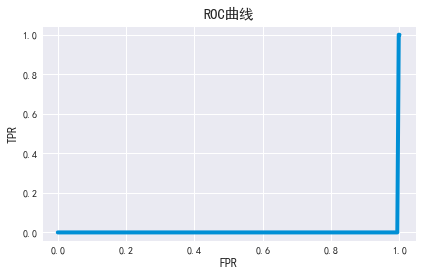

In [86]:
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
from pylab import mpl
mpl.rcParams['font.sans-serif']=['SimHei']
mpl.rcParams['axes.unicode_minus']=False
from sklearn.metrics import roc_curve

fpr1, tpr1, thersholds1 = metrics.roc_curve(label_tr.astype('int'),pre1,pos_label=2)
plt.plot(fpr1, tpr1) #绘制ROC曲线图
plt.xlabel("FPR") 
plt.ylabel("TPR")
plt.title("ROC曲线")
plt.show()   

In [87]:
from sklearn.metrics import auc
roc_auc1 = auc(fpr1, tpr1) 
roc_auc1 

0.0041823504809703205

In [141]:
# 支持向量机
from sklearn.svm import LinearSVC
model2= LinearSVC().fit(data_tr, label_tr.astype('int'))
pre2 = model2.predict(data_tr)   

In [142]:
z2 = list(df.iloc[:,[0]]['vote_average'])
sum(z2 == pre2) / len(z2)  

0.04497189256714553

In [143]:
print('查准率','查全率','F1值：')
print(metrics.classification_report(label_tr.astype('int'),pre2))

查准率 查全率 F1值：
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       0.00      0.00      0.00         3
           2       0.00      0.00      0.00        21
           3       0.00      0.00      0.00        84
           4       0.00      0.00      0.00       356
           5       0.24      0.02      0.04      1303
           6       0.43      0.98      0.59      2047
           7       0.00      0.00      0.00       903
           8       0.00      0.00      0.00        79
           9       0.00      0.00      0.00         2
          10       0.00      0.00      0.00         4

    accuracy                           0.42      4803
   macro avg       0.06      0.09      0.06      4803
weighted avg       0.25      0.42      0.26      4803



In [144]:
print('混淆矩阵：')
print(metrics.confusion_matrix(label_tr.astype('int'),pre2))   

混淆矩阵：
[[   0    0    0    0    0    0    1    0    0    0    0]
 [   0    0    0    0    0    0    3    0    0    0    0]
 [   0    0    0    0    0    2   19    0    0    0    0]
 [   0    0    0    0    0    3   81    0    0    0    0]
 [   0    0    0    0    0    8  348    0    0    0    0]
 [   0    0    0    0    0   27 1276    0    0    0    0]
 [   0    0    0    0    0   47 2000    0    0    0    0]
 [   0    0    0    0    0   21  882    0    0    0    0]
 [   0    0    0    0    0    3   76    0    0    0    0]
 [   0    0    0    0    0    0    2    0    0    0    0]
 [   0    0    0    0    0    1    3    0    0    0    0]]


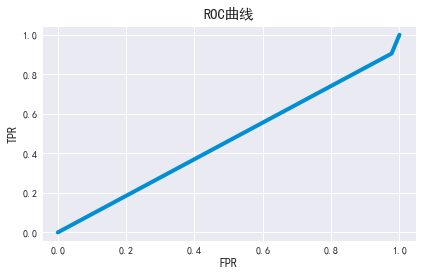

In [145]:
fpr2, tpr2, thersholds2 = metrics.roc_curve(label_tr.astype('int'),pre2,pos_label=2)
plt.plot(fpr2, tpr2) #绘制ROC曲线图
plt.xlabel("FPR") 
plt.ylabel("TPR")
plt.title("ROC曲线")
plt.show()   

In [146]:
roc_auc2 = auc(fpr2, tpr2) 
roc_auc2  

0.4638824162036207

In [102]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(data_tr,label_tr, test_size=0.3, random_state=4)

In [103]:
import xgboost
# First XGBoost model for Pima Indians dataset
from numpy import loadtxt
from xgboost import XGBClassifier 
from sklearn.metrics import accuracy_score

model3 = XGBClassifier(learning_rate=0.01)
model3.fit(X_train, y_train)  

XGBClassifier(base_score=0.5, booster='gbtree', colsample_bylevel=1,
              colsample_bynode=1, colsample_bytree=1, gamma=0, gpu_id=-1,
              importance_type='gain', interaction_constraints='',
              learning_rate=0.01, max_delta_step=0, max_depth=6,
              min_child_weight=1, missing=nan, monotone_constraints='()',
              n_estimators=100, n_jobs=0, num_parallel_tree=1,
              objective='multi:softprob', random_state=0, reg_alpha=0,
              reg_lambda=1, scale_pos_weight=None, subsample=1,
              tree_method='exact', validate_parameters=1, verbosity=None)

In [104]:
y_pred3 = model3.predict(X_test)
y_pred3  

array([4.1, 7. , 5.5, ..., 6. , 5.6, 7.7])

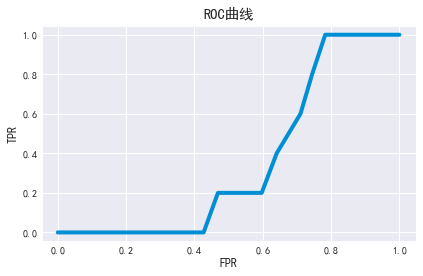

In [105]:
fpr3, tpr3, thersholds3 = metrics.roc_curve(y_test.astype('int'),y_pred3,pos_label=2)
plt.plot(fpr3, tpr3) #绘制ROC曲线图
plt.xlabel("FPR") 
plt.ylabel("TPR")
plt.title("ROC曲线")
plt.show()   

In [106]:
roc_auc3= auc(fpr3, tpr3) 
roc_auc3   

0.35341225626740946

In [107]:
from sklearn.ensemble import AdaBoostRegressor
model4 = AdaBoostRegressor(n_estimators=3)
model4.fit(X_train, y_train)
pred_y4 = model4.predict(X_test)

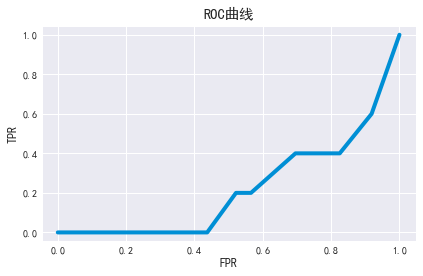

In [108]:
fpr4, tpr4, thersholds4 = metrics.roc_curve(y_test.astype('int'),pred_y4,pos_label=2)
plt.plot(fpr4, tpr4) #绘制ROC曲线图
plt.xlabel("FPR") 
plt.ylabel("TPR")
plt.title("ROC曲线")
plt.show()  

In [109]:
roc_auc4= auc(fpr4, tpr4) 
roc_auc4  

0.21991643454039

In [110]:
from sklearn.ensemble import RandomForestClassifier
RF_model=RandomForestClassifier(n_estimators=15)

In [112]:
from sklearn.model_selection import KFold
kf = KFold(n_splits=5, shuffle=True, random_state=42) 

In [113]:
from sklearn.model_selection import cross_val_score

results = []

def performance_measures(model, store_results=True):    
    train_rmses = cross_val_score(model, X_train, y_train, scoring='neg_root_mean_squared_error', cv=kf, n_jobs=-1)
    train_rmses *= -1
    train_mean_rmse = np.mean(train_rmses) 
    
    test_rmses = cross_val_score(model, X_test, y_test, scoring='neg_root_mean_squared_error', cv=kf, n_jobs=-1)
    test_rmses *= -1
    test_mean_rmse = np.mean(test_rmses)
    
    print("Train Mean RMSE: {}\nTest Mean RMSE: {}".format(train_mean_rmse, test_mean_rmse))
    
    if store_results: 
        results.append([model.__class__.__name__, train_mean_rmse, test_mean_rmse])

In [114]:
def plot_feature_importance(feature_columns, importance_values, top_n_features=15):
    feature_imp = [ col for col in zip(feature_columns, importance_values)]
    feature_imp.sort(key=lambda x:x[1], reverse=True)

    if top_n_features:
        imp = pd.DataFrame(feature_imp[:top_n_features], columns=['feature', 'importance'])
    else:
        imp = pd.DataFrame(feature_imp, columns=['feature', 'importance'])
        
    plt.figure(figsize=(10, 8))
    sns.barplot(y='feature', x='importance', data=imp, orient='h')
    plt.title('Most Important Features', fontsize=16)
    plt.ylabel("Feature", fontsize=16)
    plt.xlabel("")
    plt.show() 

In [115]:
from sklearn.linear_model import Ridge

ridge_reg = Ridge(alpha=100, random_state=42)
ridge_reg.fit(X_train, y_train)  

Ridge(alpha=100, random_state=42)

In [116]:
performance_measures(ridge_reg) 

Train Mean RMSE: 0.8286664247519028
Test Mean RMSE: 0.8886514066732824


In [117]:
from sklearn.ensemble import RandomForestRegressor

forest_reg = RandomForestRegressor(n_estimators=300, max_depth=16, max_features=0.2, n_jobs=-1, random_state=42)
forest_reg.fit(X_train, y_train)  

RandomForestRegressor(max_depth=16, max_features=0.2, n_estimators=300,
                      n_jobs=-1, random_state=42)

In [118]:
performance_measures(forest_reg)

Train Mean RMSE: 0.7803278854032276
Test Mean RMSE: 0.8252175364622328


In [119]:
from sklearn.ensemble import VotingRegressor

named_estimators = [ ('forest_reg', forest_reg), ('ridge_reg', ridge_reg)]

voting_reg = VotingRegressor(estimators=named_estimators, n_jobs=-1)
voting_reg.fit(X_train, y_train) 

VotingRegressor(estimators=[('forest_reg',
                             RandomForestRegressor(max_depth=16,
                                                   max_features=0.2,
                                                   n_estimators=300, n_jobs=-1,
                                                   random_state=42)),
                            ('ridge_reg', Ridge(alpha=100, random_state=42))],
                n_jobs=-1)

In [120]:
performance_measures(voting_reg)  

Train Mean RMSE: 0.7885603286024138
Test Mean RMSE: 0.8388171325310976


In [121]:
pd.DataFrame(results, columns=['Model', 'Train RMSLE', 'Test RMSLE']) 

,Model,Train RMSLE,Test RMSLE
0,Ridge,0.828666,0.888651
1,RandomForestRegressor,0.780328,0.825218
2,VotingRegressor,0.788560,0.838817


# 模型评估

In [123]:
pd.DataFrame(results, columns=['Model', 'Train RMSLE', 'Test RMSLE']) 

,Model,Train RMSLE,Test RMSLE
0,Ridge,0.828666,0.888651
1,RandomForestRegressor,0.780328,0.825218
2,VotingRegressor,0.788560,0.838817


在所有模型中，表决回归器可提供更好的RMLSE。我将把它作为最终模型 现在让我们看看模型在整体数据集上的表现。这将有助于您了解模型在哪里准确，在哪里不准确。RMSLE越小越好。

In [139]:
from sklearn.model_selection import cross_val_score   #交叉验证
scores=cross_val_score(forest_reg,data_tr,label_tr,cv=3)
scores.mean()

0.26002651585968806

# 模型预测

In [124]:
pre.head(n=2)  

,budget,genres,id,keywords,original_language,original_title,popularity,production_companies,production_countries,revenue,runtime,spoken_languages,title,release_year,release_month,release_day,release_dow
0,16000000.0,"Comedy,Drama,Romance",13972,"beauty salon,divorce,woman director",en,The Women,8.832100,New Line Cinema,United States of America,50007546.0,114,English,The Women,2008,9,12,4
1,15000000.0,"Drama,Romance",5038,"barcelona spain,menage a trois,author",en,Vicky Cristina Barcelona,32.758254,"The Weinstein Company,Gravier Productions,Ante...","United States of America,Spain",96408652.0,96,"Español,English",Vicky Cristina Barcelona,2008,8,15,4


In [125]:
tra= pre[['budget','genres','keywords','original_language','original_title',
               'popularity','production_companies','production_countries', 
               'revenue', 'runtime','release_year','spoken_languages','title',
               'release_month','release_day','release_dow']]
tra.head()   

,budget,genres,keywords,original_language,original_title,popularity,production_companies,production_countries,revenue,runtime,release_year,spoken_languages,title,release_month,release_day,release_dow
0,1.600000e+07,"Comedy,Drama,Romance","beauty salon,divorce,woman director",en,The Women,8.832100,New Line Cinema,United States of America,5.000755e+07,114,2008,English,The Women,9,12,4
1,1.500000e+07,"Drama,Romance","barcelona spain,menage a trois,author",en,Vicky Cristina Barcelona,32.758254,"The Weinstein Company,Gravier Productions,Ante...","United States of America,Spain",9.640865e+07,96,2008,"Español,English",Vicky Cristina Barcelona,8,15,4
2,2.500000e+07,"Action,Adventure,Drama,Romance",tv movie,sv,Arn: Tempelriddaren,6.091033,"Danmarks Radio (DR),Telepool,AMC Pictures,TV4 ...",Sweden,1.618781e+07,139,2007,"العربية,English,svenska",Arn: The Knight Templar,12,17,0
3,1.600000e+07,"Comedy,Drama,Romance","soulmates,new love,platonic love,lovers,girlfr...",en,Boys and Girls,9.119797,Punch 21 Productions,United States of America,2.062737e+07,94,2000,English,Boys and Girls,6,16,4
4,4.159073e+06,Drama,"poison,prison,loss of family,loss of father,fo...",en,White Oleander,9.423866,"Pandora Filmproduktion,John Wells Productions,...","Germany,United States of America",1.618781e+07,109,2002,English,White Oleander,10,11,4


In [126]:
train1 = tra['genres'].str.split(',',0,expand=True)
train2 = tra['keywords'].str.split(',',0,expand=True)
train3 = tra['production_companies'].str.split(',',0,expand=True)
train4 = tra['production_countries'].str.split(',',0,expand=True)
train5 = tra['spoken_languages'].str.split(',',0,expand=True)
tra['genres']=train1[0]
tra['keywords']=train1[0]
tra['production_companies']=train1[0]
tra['production_countries']=train1[0]
tra['spoken_languages']=train1[0]
tra.head() 

,budget,genres,keywords,original_language,original_title,popularity,production_companies,production_countries,revenue,runtime,release_year,spoken_languages,title,release_month,release_day,release_dow
0,1.600000e+07,Comedy,Comedy,en,The Women,8.832100,Comedy,Comedy,5.000755e+07,114,2008,Comedy,The Women,9,12,4
1,1.500000e+07,Drama,Drama,en,Vicky Cristina Barcelona,32.758254,Drama,Drama,9.640865e+07,96,2008,Drama,Vicky Cristina Barcelona,8,15,4
2,2.500000e+07,Action,Action,sv,Arn: Tempelriddaren,6.091033,Action,Action,1.618781e+07,139,2007,Action,Arn: The Knight Templar,12,17,0
3,1.600000e+07,Comedy,Comedy,en,Boys and Girls,9.119797,Comedy,Comedy,2.062737e+07,94,2000,Comedy,Boys and Girls,6,16,4
4,4.159073e+06,Drama,Drama,en,White Oleander,9.423866,Drama,Drama,1.618781e+07,109,2002,Drama,White Oleander,10,11,4


In [127]:
X3 = tra[['genres','keywords','production_companies','production_countries',
      'spoken_languages']] 
X33=pd.get_dummies(X3, drop_first=True)
X33.head()   

,genres_Action,genres_Adventure,genres_Animation,genres_Comedy,genres_Crime,genres_Documentary,genres_Drama,genres_Family,genres_Fantasy,genres_History,genres_Horror,genres_Music,genres_Mystery,genres_Romance,genres_Science Fiction,genres_TV Movie,genres_Thriller,genres_War,genres_Western,keywords_Action,keywords_Adventure,keywords_Animation,keywords_Comedy,keywords_Crime,keywords_Documentary,keywords_Drama,keywords_Family,keywords_Fantasy,keywords_History,keywords_Horror,keywords_Music,keywords_Mystery,keywords_Romance,keywords_Science Fiction,keywords_TV Movie,keywords_Thriller,keywords_War,keywords_Western,production_companies_Action,production_companies_Adventure,production_companies_Animation,production_companies_Comedy,production_companies_Crime,production_companies_Documentary,production_companies_Drama,production_companies_Family,production_companies_Fantasy,production_companies_History,production_companies_Horror,production_companies_Music,production_companies_Mystery,production_companies_Romance,production_companies_Science Fiction,production_companies_TV Movie,production_companies_Thriller,production_companies_War,production_companies_Western,production_countries_Action,production_countries_Adventure,production_countries_Animation,production_countries_Comedy,production_countries_Crime,production_countries_Documentary,production_countries_Drama,production_countries_Family,production_countries_Fantasy,production_countries_History,production_countries_Horror,production_countries_Music,production_countries_Mystery,production_countries_Romance,production_countries_Science Fiction,production_countries_TV Movie,production_countries_Thriller,production_countries_War,production_countries_Western,spoken_languages_Action,spoken_languages_Adventure,spoken_languages_Animation,spoken_languages_Comedy,spoken_languages_Crime,spoken_languages_Documentary,spoken_languages_Drama,spoken_languages_Family,spoken_languages_Fantasy,spoken_languages_History,spoken_languages_Horror,spoken_languages_Music,spoken_languages_Mystery,spoken_languages_Romance,spoken_languages_Science Fiction,spoken_languages_TV Movie,spoken_languages_Thriller,spoken_languages_War,spoken_languages_Western
0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0


In [128]:
X4 = tra[['budget','popularity','revenue','runtime']] 
scaler=StandardScaler()
X44=scaler.fit_transform(X4)
X44=pd.DataFrame(X44,columns=['budget','popularity','revenue','runtime'])
X44.head() 

,budget,popularity,revenue,runtime
0,2.541634,-0.142821,0.617604,0.526289
1,2.298457,1.507281,1.706888,-0.296323
2,4.730225,-0.331862,-0.176327,1.668808
3,2.541634,-0.122979,-0.072107,-0.387725
4,-0.337804,-0.102009,-0.176327,0.297786


In [129]:
X_try=pd.concat([X33,X44],axis=1)
X_try.head()  

,genres_Action,genres_Adventure,genres_Animation,genres_Comedy,genres_Crime,genres_Documentary,genres_Drama,genres_Family,genres_Fantasy,genres_History,genres_Horror,genres_Music,genres_Mystery,genres_Romance,genres_Science Fiction,genres_TV Movie,genres_Thriller,genres_War,genres_Western,keywords_Action,keywords_Adventure,keywords_Animation,keywords_Comedy,keywords_Crime,keywords_Documentary,keywords_Drama,keywords_Family,keywords_Fantasy,keywords_History,keywords_Horror,keywords_Music,keywords_Mystery,keywords_Romance,keywords_Science Fiction,keywords_TV Movie,keywords_Thriller,keywords_War,keywords_Western,production_companies_Action,production_companies_Adventure,production_companies_Animation,production_companies_Comedy,production_companies_Crime,production_companies_Documentary,production_companies_Drama,production_companies_Family,production_companies_Fantasy,production_companies_History,production_companies_Horror,production_companies_Music,production_companies_Mystery,production_companies_Romance,production_companies_Science Fiction,production_companies_TV Movie,production_companies_Thriller,production_companies_War,production_companies_Western,production_countries_Action,production_countries_Adventure,production_countries_Animation,production_countries_Comedy,production_countries_Crime,production_countries_Documentary,production_countries_Drama,production_countries_Family,production_countries_Fantasy,production_countries_History,production_countries_Horror,production_countries_Music,production_countries_Mystery,production_countries_Romance,production_countries_Science Fiction,production_countries_TV Movie,production_countries_Thriller,production_countries_War,production_countries_Western,spoken_languages_Action,spoken_languages_Adventure,spoken_languages_Animation,spoken_languages_Comedy,spoken_languages_Crime,spoken_languages_Documentary,spoken_languages_Drama,spoken_languages_Family,spoken_languages_Fantasy,spoken_languages_History,spoken_languages_Horror,spoken_languages_Music,spoken_languages_Mystery,spoken_languages_Romance,spoken_languages_Science Fiction,spoken_languages_TV Movie,spoken_languages_Thriller,spoken_languages_War,spoken_languages_Western,budget,popularity,revenue,runtime
0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2.541634,-0.142821,0.617604,0.526289
1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,2.298457,1.507281,1.706888,-0.296323
2,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,4.730225,-0.331862,-0.176327,1.668808
3,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2.541634,-0.122979,-0.072107,-0.387725
4,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,-0.337804,-0.102009,-0.176327,0.297786


In [130]:
df1 = X_try[['genres_Comedy','genres_Drama',
             'genres_Horror','popularity','revenue','runtime']]
df1.head(3)   

,genres_Comedy,genres_Drama,genres_Horror,popularity,revenue,runtime
0,1,0,0,-0.142821,0.617604,0.526289
1,0,1,0,1.507281,1.706888,-0.296323
2,0,0,0,-0.331862,-0.176327,1.668808


In [131]:
df2 = pre[['release_month','release_day','budget','release_dow','release_year']] 
df2 .head()  

,release_month,release_day,budget,release_dow,release_year
0,9,12,1.600000e+07,4,2008
1,8,15,1.500000e+07,4,2008
2,12,17,2.500000e+07,0,2007
3,6,16,1.600000e+07,4,2000
4,10,11,4.159073e+06,4,2002


In [132]:
df3=pd.concat([df1,df2],axis=1)
df3.head()    

,genres_Comedy,genres_Drama,genres_Horror,popularity,revenue,runtime,release_month,release_day,budget,release_dow,release_year
0,1,0,0,-0.142821,0.617604,0.526289,9,12,1.600000e+07,4,2008
1,0,1,0,1.507281,1.706888,-0.296323,8,15,1.500000e+07,4,2008
2,0,0,0,-0.331862,-0.176327,1.668808,12,17,2.500000e+07,0,2007
3,1,0,0,-0.122979,-0.072107,-0.387725,6,16,1.600000e+07,4,2000
4,0,1,0,-0.102009,-0.176327,0.297786,10,11,4.159073e+06,4,2002


In [135]:
predicted_vote_average = forest_reg.predict(df3)
overall_data = df3.copy()
overall_data['vote_average'] = predicted_vote_average.copy() 

In [136]:
overall_data.head(n=2)

,genres_Comedy,genres_Drama,genres_Horror,popularity,revenue,runtime,release_month,release_day,budget,release_dow,release_year,vote_average
0,1,0,0,-0.142821,0.617604,0.526289,9,12,16000000.0,4,2008,6.454921
1,0,1,0,1.507281,1.706888,-0.296323,8,15,15000000.0,4,2008,6.984362


In [148]:
a=overall_data[['vote_average']]
b = pd.read_csv('F:/大三（上）/机器学习/机器学习期末报告/机器学习期末报告/电影数据分析/data/tmdb_1000_predict.csv',encoding='utf-8')
c=pd.concat([a,b],axis=1)
c.head()  

,vote_average,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,title,vote_average,vote_count
0,6.454921,16000000,"[{""id"": 35, ""name"": ""Comedy""}, {""id"": 18, ""nam...",http://thewomen.warnerbros.com/index.html,13972,"[{""id"": 9749, ""name"": ""beauty salon""}, {""id"": ...",en,The Women,"The story centers on a group of gossipy, high-...",8.832100,"[{""name"": ""New Line Cinema"", ""id"": 12}]","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2008/9/12,50007546,114,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,NaN,The Women,NaN,NaN
1,6.984362,15000000,"[{""id"": 18, ""name"": ""Drama""}, {""id"": 10749, ""n...",NaN,5038,"[{""id"": 107, ""name"": ""barcelona spain""}, {""id""...",en,Vicky Cristina Barcelona,Two girlfriends on a summer holiday in Spain b...,32.758254,"[{""name"": ""The Weinstein Company"", ""id"": 308},...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2008/8/15,96408652,96,"[{""iso_639_1"": ""es"", ""name"": ""Espa\u00f1ol""}, ...",Released,Life is the ultimate work of art,Vicky Cristina Barcelona,NaN,NaN
2,6.549892,25000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",NaN,13491,"[{""id"": 156321, ""name"": ""tv movie""}]",sv,Arn: Tempelriddaren,"Arn, the son of a high-ranking Swedish noblema...",6.091033,"[{""name"": ""Danmarks Radio (DR)"", ""id"": 119}, {...","[{""iso_3166_1"": ""SE"", ""name"": ""Sweden""}]",2007/12/17,0,139,"[{""iso_639_1"": ""ar"", ""name"": ""\u0627\u0644\u06...",Released,A Knight in the Holy Land. A Woman in the Froz...,Arn: The Knight Templar,NaN,NaN
3,6.089306,16000000,"[{""id"": 35, ""name"": ""Comedy""}, {""id"": 18, ""nam...",NaN,10571,"[{""id"": 815, ""name"": ""soulmates""}, {""id"": 1605...",en,Boys and Girls,Ryan and Jennifer are opposites who definitely...,9.119797,"[{""name"": ""Punch 21 Productions"", ""id"": 13158}]","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2000/6/16,20627372,94,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,Warning: Sex Changes Everything,Boys and Girls,NaN,NaN
4,7.005494,0,"[{""id"": 18, ""name"": ""Drama""}]",NaN,10994,"[{""id"": 351, ""name"": ""poison""}, {""id"": 378, ""n...",en,White Oleander,A teenager journeys through a series of foster...,9.423866,"[{""name"": ""Pandora Filmproduktion"", ""id"": 254}...","[{""iso_3166_1"": ""DE"", ""name"": ""Germany""}, {""is...",2002/10/11,0,109,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,NaN,White Oleander,NaN,NaN


In [149]:
# 保存 csv
c.to_csv(path_or_buf='F:/大三（上）/机器学习/机器学习期末报告/机器学习期末报告/电影数据分析/data/tmdb_1000_predicted.csv',index=False)